# cir2c — RQ2 / RQ3 analysis

Parsing of the BenchExec result files under `../results/results/normalized/`.

## Research Questions

- RQ1, Completeness *(different analysis)*: how much of contemporary C++ does the pipeline accept end-to-end?
- RQ2, Soundness: when it produces a translation, does a C verifier reach the same verdict the C++ source warrants?
- RQ3, Performance: what does verifying the transformed C cost, compared to verifying C++ directly?


## The four task sets (configs)

There is one original C++ suite and three mapped-C suites that differ in how the C++
standard library is handled by cir2c:

- **`cpp-baseline`** — the original C++ tasks, run only by the natively-C++ verifiers.
  Filtered to tasks that actually contain an assertion: the property is assertion failure
  (`reach_error` reachability), so a task with no assert is meaningless for it, and those
  assert-free tasks were also the main source of mislabeling, so they were dropped.
- **`c-exact_std`** — cir2c output with the std library mapped *accurately* (no
  over-approximation). May still contain unlinked `extern` functions, i.e. some function
  definitions are missing.
- **`c-nohavoc_std`** — same as `c-exact_std`, but the tasks that still have undefined
  `extern` functions are filtered out (so every called function has a definition).
- **`c-havoc_std`** — std library functions (and other unmodelled calls) are *havoc'd*:
  they may return anything. This is an over-approximation, which shows up in the results
  (e.g. spurious property violations / wrong verdicts).

By task name the mapped sets nest inside the C++ baseline:
`c-nohavoc_std` ⊆ `c-exact_std` ⊆ `c-havoc_std` ⊆ `cpp-baseline`. The relationships are by
construction: `c-havoc_std` is the most permissive mapping (it can map tasks an accurate
std mapping cannot), `c-exact_std` is the accurately-mapped subset, `c-nohavoc_std` drops
the `c-exact_std` tasks with leftover undefined `extern`s, and `cpp-baseline` additionally
holds the C++ tasks cir2c could not map. The inclusions need not be strict — in the current
data `c-exact_std` and `c-havoc_std` cover the same tasks. The coverage cell below verifies
the chain and prints the exact counts; the shared-task / dual-majority cells report the
overlaps with `cpp-baseline`.

## Tools per config

- **Every verifier** runs the mapped-C suites.
- **Only the natively-C++-capable verifiers** (`esbmc-kind`, `cbmc`, `divine`) additionally
  run `cpp-baseline`. `cbmc` is then **excluded as a native-C++ verifier** (it solves only a
  small fragment of the C++ suite) so it does not skew the C++ consensus, but it stays an
  ordinary mapped-C verifier.
- Verifiers that never return a single true/false verdict are dropped right after parsing;
  the drop cell prints which ones and how many verifiers remain on each role.

The full tool list, suite list, and all counts are printed by the cells below.

In [82]:
import bz2
import re
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd

RESULTS_DIR = Path("../results/results/normalized")

# Verifiers that natively handle C++ and so also ran the original (un-mapped) suite.
# This is the one fixed fact. Suite/config names are *discovered* from the result
# files (next cell), so renamed suites or additional mapped suites need no edits here.
NATIVE_CPP_TOOLS = ["esbmc-kind", "cbmc", "divine"]

# Verifiers excluded *as native-C++ verifiers only* (their rows on the C++ suite are
# dropped): they solve only a fragment of the C++ suite and would skew its consensus.
# They are kept as ordinary mapped-C verifiers.
CPP_EXCLUDE = ["cbmc"]

# Tools dropped entirely from every suite/view — e.g. known-bad voters identified
# by investigation. Currently: mopsa never produces a correct "false" (bug-found)
# verdict anywhere in c-exact_std, only correct/wrong "true"s, so it can only ever
# hurt the unsound (missed-bug) direction of the majority vote.
TOOL_BLOCKLIST = []

# Minimum votes the winning side needs for a task to get a strict true/false
# majority (see collapse() below); short of that the per-task majority is demoted
# to "unknown" instead of trusting a thin/lone-wolf vote. 1 = any nonzero lead
# decides; raise it to require broader agreement. Split by language because the
# mapped-C suites have many verifiers while the original C++ suite has only the
# NATIVE_CPP_TOOLS (minus CPP_EXCLUDE); min_votes_for() (next to collapse())
# picks the threshold per suite.
MIN_MAJORITY_VOTES_C = 2     # mapped-C suites (MAPPED_CONFIGS)
MIN_MAJORITY_VOTES_CPP = 1   # original C++ suite(s) (ORIGINAL_CONFIGS)

# <tool>.<YYYY-MM-DD_HH-MM-SS>.results.<config>.<config>.xml.bz2
FNAME_RE = re.compile(
    r"^(?P<tool>.+?)\.(?P<date>\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})\.results\.(?P<config>[^.]+)\."
)


In [83]:
def _seconds(v):
    """'0.123s' -> 0.123 ; None/garbage -> NaN."""
    if not v:
        return np.nan
    v = v.strip().rstrip("s")
    try:
        return float(v)
    except ValueError:
        return np.nan


def _bytes(v):
    """'5607424B' -> 5607424.0 ; None/garbage -> NaN."""
    if not v:
        return np.nan
    v = v.strip().rstrip("B")
    try:
        return float(v)
    except ValueError:
        return np.nan


def _verdict(status):
    """Collapse a raw BenchExec status to true / false / unknown."""
    s = (status or "").lower()
    if s.startswith("true"):
        return "true"
    if s.startswith("false"):
        return "false"
    return "unknown"  # timeout, out of memory, any ERROR/EXCEPTION, plain 'unknown'


def parse_file(path: Path) -> list[dict]:
    m = FNAME_RE.match(path.name)
    tool, config = m["tool"], m["config"]
    root = ET.fromstring(bz2.open(path).read())
    out = []
    for run in root.findall("run"):
        cols = {c.get("title"): c.get("value") for c in run.findall("column")}
        name = run.get("name")
        out.append(
            {
                "tool": tool,
                "config": config,
                "task": name,                       # joins across suites (normalized)
                "group": name.split("/", 1)[0],     # algorithm / cbmc / ... (SV-COMP-style group)
                "expected": run.get("expectedVerdict"),   # ground-truth label: true / false
                "status": cols.get("status"),             # raw verifier status
                "bx_category": cols.get("category"),       # BenchExec: correct/wrong/unknown/error
                "verdict": _verdict(cols.get("status")),   # true / false / unknown
                "cputime": _seconds(cols.get("cputime")),  # seconds
                "walltime": _seconds(cols.get("walltime")),  # seconds
                "memory": _bytes(cols.get("memory")),      # bytes
                "termination": cols.get("terminationreason"),
            }
        )
    return out


# A tool/suite may have several timestamped runs (re-runs); keep only the latest.
# Filenames embed YYYY-MM-DD_HH-MM-SS, which sorts chronologically as text, so the
# last file seen per (tool, config) is the newest. Keying on (tool, config) means a
# re-run of one suite does not discard the other suites' runs.
latest = {}
for f in sorted(RESULTS_DIR.glob("*.xml.bz2")):
    m = FNAME_RE.match(f.name)
    latest[(m["tool"], m["config"])] = f  # later date overwrites earlier
df = pd.DataFrame([row for f in latest.values() for row in parse_file(f)])

# --- Discover suites from the data (robust to renames and to extra mapped suites) ---
# A "mapped" suite is any C suite run by more verifiers than just the native-C++ trio;
# the original C++ suite(s) are run only by those. No suite name is hardcoded.
tools_per_config = df.groupby("config").tool.nunique()
MAPPED_CONFIGS = sorted(tools_per_config.index[tools_per_config > len(NATIVE_CPP_TOOLS)])
ORIGINAL_CONFIGS = sorted(c for c in tools_per_config.index if c not in MAPPED_CONFIGS)
CONFIGS = ORIGINAL_CONFIGS + MAPPED_CONFIGS  # display order: originals first

df["config"] = pd.Categorical(df["config"], CONFIGS, ordered=True)
# Correctness of the verdict vs. the suite label: True / False / NaN(=inconclusive).
df["correct"] = df["bx_category"].map({"correct": True, "wrong": False})

print(f"{len(df):,} rows | {df.tool.nunique()} tools")
print(f"  mapped suites:   {MAPPED_CONFIGS}")
print(f"  original suites: {ORIGINAL_CONFIGS}")
df.head()


99,282 rows | 29 tools
  mapped suites:   ['c-exact_std', 'c-havoc_std', 'c-nohavoc_std']
  original suites: ['cpp-baseline']


,tool,config,task,group,expected,status,bx_category,verdict,cputime,walltime,memory,termination,correct
0,2ls,c-exact_std,algorithm/algorithm1/algorithm_algorithm1.yml,algorithm,true,unknown,unknown,unknown,0.262984,0.257245,20459520.0,None,NaN
1,2ls,c-exact_std,algorithm/algorithm10/algorithm_algorithm10.yml,algorithm,true,unknown,unknown,unknown,0.150743,8.535311,9048064.0,None,NaN
2,2ls,c-exact_std,algorithm/algorithm100/algorithm_algorithm100.yml,algorithm,false,unknown,unknown,unknown,0.446578,0.444752,34074624.0,None,NaN
3,2ls,c-exact_std,algorithm/algorithm100_stable_sort/algorithm_a...,algorithm,false,unknown,unknown,unknown,0.536390,7.432167,41267200.0,None,NaN
4,2ls,c-exact_std,algorithm/algorithm101/algorithm_algorithm101.yml,algorithm,false,unknown,unknown,unknown,0.231301,1.415039,21803008.0,None,NaN


In [84]:
# Drop C verifiers that never produced a single true/false verdict (only unknown) —
# they contribute nothing to verdict agreement. Done right after parsing so every
# downstream cell sees only the conclusive verifiers.
conclusive_tools = df.loc[df.verdict.isin(["true", "false"]), "tool"].unique()
dropped_tools = sorted(set(df.tool) - set(conclusive_tools))
df = df[df.tool.isin(conclusive_tools)].copy()
print(f"Dropped {len(dropped_tools)} unknown-only verifiers: {dropped_tools}")

# Drop blocklisted tools entirely, from every suite (see TOOL_BLOCKLIST above).
df = df[~df.tool.isin(TOOL_BLOCKLIST)].copy()
print(f"Blocklisted {TOOL_BLOCKLIST}: dropped from all suites")

# Drop CPP_EXCLUDE verifiers from the original C++ suite(s) only (they remain on the
# mapped-C suites). ORIGINAL_CONFIGS comes from the discovery in the previous cell.
df = df[~(df.tool.isin(CPP_EXCLUDE) & df.config.isin(ORIGINAL_CONFIGS))].copy()
print(f"Excluded {CPP_EXCLUDE} from C++ suite(s) {ORIGINAL_CONFIGS}")

print(f"Remaining verifiers: {df[df.config.isin(ORIGINAL_CONFIGS)].tool.nunique()} on C++, "
      f"{df[df.config.isin(MAPPED_CONFIGS)].tool.nunique()} on mapped-C")


Dropped 5 unknown-only verifiers: ['cpv', 'graves', 'infer', 're3ver', 'veriabsl']
Blocklisted []: dropped from all suites
Excluded ['cbmc'] from C++ suite(s) ['cpp-baseline']
Remaining verifiers: 2 on C++, 24 on mapped-C


In [85]:
# Which tool ran which suite, and on how many tasks (blank = not run).
runs = df.pivot_table(
    index="tool", columns="config", values="task", aggfunc="count", observed=False
)
display(runs)

# Per-suite outcome breakdown (verdict vs. suite label).
summary = (
    df.groupby("config", observed=True)
    .agg(
        runs=("task", "count"),
        correct=("correct", lambda s: int((s == True).sum())),
        wrong=("correct", lambda s: int((s == False).sum())),
        inconclusive=("verdict", lambda s: int((s == "unknown").sum())),
        said_true=("verdict", lambda s: int((s == "true").sum())),
        said_false=("verdict", lambda s: int((s == "false").sum())),
    )
)
display(summary)


config,cpp-baseline,c-exact_std,c-havoc_std,c-nohavoc_std
tool,,,,
2ls,0,1010,1010,980
bubaak,0,1010,1010,980
bubaak-split,0,1010,1010,980
cbmc,0,1010,1010,980
cpachecker,0,1010,1010,980
crux,0,1010,1010,980
divine,1094,1010,1010,980
emergentheta,0,1010,1010,980
esbmc-kind,1094,1010,1010,980


,runs,correct,wrong,inconclusive,said_true,said_false
config,,,,,,
cpp-baseline,2188,1477,98,613,1122,453
c-exact_std,27270,5372,1906,19992,5481,1797
c-havoc_std,27270,7241,4803,15226,5779,6265
c-nohavoc_std,26460,5273,1786,19401,5367,1692


## Sanity check: coverage & task-set nesting

The run matrix above is *count*-uniform; this confirms it is also *set*-uniform — every
retained verifier ran the identical task set within each suite (no silent gaps, no task run
twice), so the agreement triples below are taken over a fixed task set. It also verifies the
suites nest by task name as the intro claims, and prints the actual inclusions.

In [86]:
# Per suite, every retained verifier must have run the *identical* task set (equal run
# counts above are necessary but not sufficient) and no task twice — otherwise the
# agreement triples below would be over a moving set.
for cfg in CONFIGS:
    sub = df[df.config == cfg]
    tools = sorted(sub.tool.unique())
    tasksets = {t: set(sub[sub.tool == t].task) for t in tools}
    union = set().union(*tasksets.values())
    gaps = {t: len(union - ts) for t, ts in tasksets.items() if union - ts}
    dup = int((sub.groupby(["tool", "task"]).size() > 1).sum())
    ok = not gaps and not dup
    print(f"[{'OK ' if ok else 'BAD'}] {cfg}: {len(tools)} verifiers x {len(union)} tasks"
          + (f"  | gaps: {gaps}" if gaps else "")
          + (f"  | {dup} duplicate (tool,task) rows" if dup else ""))

# Suite nesting by task name (subset, not necessarily strict): order suites by size and
# check each is contained in the next, so the intro's chain is verified, not just asserted.
suites = {c: set(df[df.config == c].task.unique()) for c in CONFIGS}
chain = sorted(suites, key=lambda c: len(suites[c]))
print("\nTask-set nesting (smallest -> largest):")
for a, b in zip(chain, chain[1:]):
    rel = ("=="        if suites[a] == suites[b]
           else "subset of" if suites[a] <= suites[b]
           else "NOT subset of")
    print(f"  {a} ({len(suites[a])}) {rel} {b} ({len(suites[b])})"
          f"   [only in {a}: {len(suites[a] - suites[b])}]")

[OK ] cpp-baseline: 2 verifiers x 1094 tasks
[BAD] c-exact_std: 24 verifiers x 1010 tasks  | 3030 duplicate (tool,task) rows
[BAD] c-havoc_std: 24 verifiers x 1010 tasks  | 3030 duplicate (tool,task) rows
[BAD] c-nohavoc_std: 24 verifiers x 980 tasks  | 2940 duplicate (tool,task) rows

Task-set nesting (smallest -> largest):
  c-nohavoc_std (980) subset of c-exact_std (1010)   [only in c-nohavoc_std: 0]
  c-exact_std (1010) == c-havoc_std (1010)   [only in c-exact_std: 0]
  c-havoc_std (1010) subset of cpp-baseline (1094)   [only in c-havoc_std: 0]


## Sanity check: answers returned on the mapped (C) suites

Every distinct BenchExec `category` and raw verifier `status` produced by the C
verifiers, and how each status collapses into our `true` / `false` / `unknown`.


In [87]:
# Restrict to the mapped (C) suites — these are what the C verifiers actually consume.
mapped = df[df.config.isin(MAPPED_CONFIGS)]

print("BenchExec categories:", sorted(mapped.bx_category.dropna().unique()))
print(f"Distinct raw statuses: {mapped.status.nunique()}\n")

status_tbl = (
    mapped.groupby("status")
    .agg(verdict=("verdict", "first"), n=("task", "size"))
    .sort_values("n", ascending=False)
)
status_tbl


BenchExec categories: ['correct', 'error', 'unknown', 'wrong']
Distinct raw statuses: 33



,verdict,n
status,,
true,true,16627
unknown,unknown,15435
TIMEOUT,unknown,11312
false(unreach-call),false,9754
"ERROR (frontend failed, before parsing finished)",unknown,6627
ERROR (6),unknown,3001
ERROR (134),unknown,2993
unknown(no override),unknown,2249
TIMEOUT (EXCEPTION (Sys_error)),unknown,2248


## Sanity check: C++ verifier verdicts vs the labels

The native-C++ verifiers (`divine`, `esbmc-kind`) are the C++ reference for RQ2, so it matters
how often they themselves disagree with the ground-truth `expected_verdict` on the C++ baseline
(only those two run it; `cbmc` already excluded). Per verifier: `correct` / `wrong` / `unknown`
counts and, among the wrong ones, `missed_bug` (said *true* on a label-*false* task, i.e. claimed
safe and missed the violation) versus `false_alarm` (said *false* on a label-*true* task, i.e. a
spurious violation). `wrong_pct` is wrong over all runs.

In [88]:
# How often do the native-C++ verifiers disagree with the ground-truth labels? Their
# verdicts are the C++ reference for RQ2, so wrong answers here matter. On the C++ baseline,
# cross each verifier's verdict against the suite label. `missed_bug` = said true on a
# label-false task (claims safe, misses the bug); `false_alarm` = said false on a label-true
# task (spurious violation).
cpp = df[df.config == "cpp-baseline"]
rows = {}
for tool, g in cpp.groupby("tool"):
    wrong = g[g.bx_category == "wrong"]
    rows[tool] = {
        "runs": len(g),
        "correct": int((g.bx_category == "correct").sum()),
        "wrong": len(wrong),
        "missed_bug": int(((wrong.verdict == "true") & (wrong.expected == "false")).sum()),
        "false_alarm": int(((wrong.verdict == "false") & (wrong.expected == "true")).sum()),
        "unknown": int((g.verdict == "unknown").sum()),
    }
cpp_label_check = pd.DataFrame(rows).T
cpp_label_check["wrong_pct"] = (100 * cpp_label_check["wrong"] / cpp_label_check["runs"]).round(2)
cpp_label_check

,runs,correct,wrong,missed_bug,false_alarm,unknown,wrong_pct
divine,1094,537,18,18,0,539,1.65
esbmc-kind,1094,940,80,47,33,74,7.31


In [89]:
import matplotlib.pyplot as plt

# Export targets: figures/<rq>/ holds <name>.pdf (plots) and <name>.tex (a figure or
# table environment that \input-s into the paper).
#
# FIG_ROOT is where this notebook writes artifacts. PAPER_FIG_DIR is the prefix baked into
# the \includegraphics paths inside the generated .tex: in the paper the figures live under
# <paper>/figures/results/rq23/<rq>/ (this figures/ folder is copied there), and the prefix
# is relative to the main paper .tex. So a generated figure .tex can be \input directly.
FIG_ROOT = Path("figures")              # where this notebook writes the .pdf/.tex artifacts
PAPER_FIG_DIR = "figures/results/rq23"  # \includegraphics prefix, relative to the paper's main .tex
for _rq in ("rq2", "rq3"):
    (FIG_ROOT / _rq).mkdir(parents=True, exist_ok=True)

# Every export appends here so figures/README.md can be regenerated from the exact set of
# artifacts this run produced (see the manifest cell at the end). Reset on each run of this
# cell so a top-to-bottom execution starts clean.
MANIFEST = []


def export_fig(fig, rq, name, caption, label=None, width=r"\linewidth"):
    """Save fig as figures/<rq>/<name>.pdf + a sibling .tex figure environment, show it."""
    label = label or "fig:" + name.replace("_", "-")
    fig.savefig(FIG_ROOT / rq / f"{name}.pdf", bbox_inches="tight")
    (FIG_ROOT / rq / f"{name}.tex").write_text(
        "\\begin{figure}[t]\n  \\centering\n"
        f"  \\includegraphics[width={width}]{{{PAPER_FIG_DIR}/{rq}/{name}.pdf}}\n"
        f"  \\caption{{{caption}}}\n  \\label{{{label}}}\n"
        "\\end{figure}\n",
        encoding="utf-8",
    )
    MANIFEST.append(dict(rq=rq, name=name, kind="figure", label=label, caption=caption))
    display(fig)
    plt.close(fig)


def export_table(frame, rq, name, caption, label=None, **to_latex_kw):
    """Write a LaTeX table environment wrapping frame.to_latex to figures/<rq>/<name>.tex."""
    label = label or "tab:" + name.replace("_", "-")
    opts = dict(index=True, escape=True, float_format="%.4g")
    opts.update(to_latex_kw)
    (FIG_ROOT / rq / f"{name}.tex").write_text(
        "\\begin{table}[t]\n  \\centering\n"
        f"  \\caption{{{caption}}}\n  \\label{{{label}}}\n"
        f"{frame.to_latex(**opts)}"
        "\\end{table}\n",
        encoding="utf-8",
    )
    MANIFEST.append(dict(rq=rq, name=name, kind="table", label=label, caption=caption))
    return frame  # so callers can `display(export_table(...))`

## Verifier agreement per task

For each task we collapse the answers of the retained C verifiers into a triple
`(#true, #false, #unknown)` (the three sum to the number of retained verifiers). We
then count, **per mapped suite and per ground-truth label**, how many tasks share each
triple — i.e. how many tasks the verifiers (dis)agreed on in the same way.

`label` is the suite's ground-truth `expected_verdict`; `n_tasks` is how many tasks
fall into that exact agreement pattern.


In [90]:
def agreement_table(cfg: str) -> pd.DataFrame:
    """Per task: (#true,#false,#unknown) over the C verifiers, then count tasks per
    (label, triple). One row per distinct agreement pattern."""
    sub = df[df.config == cfg]
    per_task = (
        sub.pivot_table(index=["task", "expected"], columns="verdict",
                        values="tool", aggfunc="count", fill_value=0)
        .reindex(columns=["true", "false", "unknown"], fill_value=0)
        .reset_index()
        .rename(columns={"expected": "label"})
    )
    return (
        per_task.groupby(["label", "true", "false", "unknown"])
        .size().reset_index(name="n_tasks")
        .sort_values(["label", "n_tasks"], ascending=[True, False])
        .reset_index(drop=True)
    )


agreement = {cfg: agreement_table(cfg) for cfg in MAPPED_CONFIGS}
for cfg, tbl in agreement.items():
    print(f"\n===== {cfg}: {tbl.n_tasks.sum()} tasks, "
          f"{len(tbl)} distinct (true,false,unknown) patterns =====")
    display(tbl)



===== c-exact_std: 1010 tasks, 108 distinct (true,false,unknown) patterns =====


,label,true,false,unknown,n_tasks
0,false,3,0,24,79
1,false,3,2,22,73
2,false,3,3,21,38
3,false,4,1,22,34
4,false,3,4,20,31
...,...,...,...,...,...
103,true,16,1,10,1
104,true,17,2,8,1
105,true,20,0,7,1
106,true,20,1,6,1



===== c-havoc_std: 1010 tasks, 110 distinct (true,false,unknown) patterns =====


,label,true,false,unknown,n_tasks
0,false,4,10,13,56
1,false,3,6,18,42
2,false,4,7,16,33
3,false,3,10,14,32
4,false,3,9,15,28
...,...,...,...,...,...
105,true,16,1,10,1
106,true,17,2,8,1
107,true,20,0,7,1
108,true,20,1,6,1



===== c-nohavoc_std: 980 tasks, 102 distinct (true,false,unknown) patterns =====


,label,true,false,unknown,n_tasks
0,false,3,0,24,76
1,false,3,2,22,72
2,false,3,3,21,42
3,false,4,1,22,33
4,false,3,5,19,30
...,...,...,...,...,...
97,true,16,1,10,1
98,true,17,2,8,1
99,true,20,0,7,1
100,true,20,1,6,1


## Collapsed agreement views

Two coarser per-task labels derived from the verifier votes, to weigh against the full
per-pattern breakdown above:

- **majority** — true vs false only (unknowns ignored): `true`/`false` when that side has
  strictly more votes *and* at least the suite's vote threshold (`MIN_MAJORITY_VOTES_C` = 2
  on the mapped-C suites, `MIN_MAJORITY_VOTES_CPP` = 1 on the C++ suite), so a single
  lone-wolf vote cannot carry a suite with many verifiers; `tie` when true and false are
  equal but both clear the threshold; `unknown` when no verifier decided *or* the leading
  side falls short of the threshold.
- **unanimous** — among verifiers that gave *any* verdict: `all-true` / `all-false` /
  `conflict` (both true and false seen) / `none` (no verdict at all).

Rows are the ground-truth `label`; cells count tasks.

In [91]:
def per_task_counts(cfg: str) -> pd.DataFrame:
    """One row per task: columns label, true, false, unknown (vote counts)."""
    return (
        df[df.config == cfg]
        .pivot_table(index=["task", "expected"], columns="verdict",
                     values="tool", aggfunc="count", fill_value=0)
        .reindex(columns=["true", "false", "unknown"], fill_value=0)
        .reset_index()
        .rename(columns={"expected": "label"})
    )


def min_votes_for(cfg: str) -> int:
    """Min winning-side votes for a strict majority on `cfg`: the C++ threshold for the
    original C++ suite(s), the mapped-C threshold for everything else."""
    return MIN_MAJORITY_VOTES_CPP if cfg in ORIGINAL_CONFIGS else MIN_MAJORITY_VOTES_C


def collapse(pt: pd.DataFrame, min_votes: int) -> pd.DataFrame:
    """Add `majority` and `unanimous` per-task labels to a per_task_counts frame.

    `min_votes` is the minimum winning-side vote count for a strict majority; pass
    `min_votes_for(cfg)` so the C and C++ suites use their own thresholds."""
    pt = pt.copy()
    # Majority is decided on true vs false only (unknowns ignored): `unknown` when no
    # verifier gave any verdict *or* the winning side falls short of
    # min_votes (too thin/lone-wolf a vote to trust as a "majority"), `tie`
    # when true and false votes are equal but nonzero (and clear min_votes).
    winner_votes = np.maximum(pt.true, pt.false)
    enough_votes = winner_votes >= min_votes
    pt["majority"] = np.select(
        [~enough_votes, pt.true > pt.false, pt.false > pt.true],
        ["unknown", "true", "false"],
        default="tie",
    )
    pt["unanimous"] = np.select(
        [(pt.true > 0) & (pt.false > 0), pt.true > 0, pt.false > 0],
        ["conflict", "all-true", "all-false"],
        default="none",
    )
    return pt


for cfg in MAPPED_CONFIGS:
    pt = collapse(per_task_counts(cfg), min_votes_for(cfg))
    print(f"\n===== {cfg} ({len(pt)} tasks) =====")
    maj = pd.crosstab(pt.label, pt.majority).rename_axis(columns="majority")
    una = pd.crosstab(pt.label, pt.unanimous).rename_axis(columns="unanimous")
    display(export_table(maj, "rq2", f"majority_{cfg}",
                         f"Per-task majority verdict vs.\\ ground-truth label on "
                         f"\\texttt{{{cfg}}} (true vs.\\ false; unknowns ignored).",
                         label=f"tab:majority-{cfg}"))
    display(export_table(una, "rq2", f"unanimous_{cfg}",
                         f"Per-task unanimity among deciding verifiers vs.\\ ground-truth "
                         f"label on \\texttt{{{cfg}}}.",
                         label=f"tab:unanimous-{cfg}"))



===== c-exact_std (1010 tasks) =====


majority,false,tie,true,unknown
label,,,,
false,130,49,280,2
true,13,9,525,2


unanimous,all-true,conflict,none
label,,,
false,104,356,1
true,396,152,1



===== c-havoc_std (1010 tasks) =====


majority,false,tie,true
label,,,
false,355,29,77
true,279,61,209


unanimous,all-true,conflict
label,,
false,2,459
true,84,465



===== c-nohavoc_std (980 tasks) =====


majority,false,tie,true,unknown
label,,,,
false,122,49,272,2
true,8,1,524,2


unanimous,all-true,conflict,none
label,,,
false,97,347,1
true,398,136,1


## Majority strength: how overwhelming is the consensus

For every task with a strict majority (`majority` in {`true`, `false`}; ties and
all-unknown excluded), count the verifiers voting **against** the majority — `false`
votes when the majority is `true` and vice versa, ignoring unknowns. This is the
dissent, and it measures how lopsided each majority is. The table reports, per mapped
suite, the dissent's min / median / mean / max, the share of strict majorities that are
unanimous (zero dissent), and the mean dissent as a percentage of the deciding verifiers
(`deciders = #true + #false`, which varies per task because of unknowns). The inline
splits break the same dissent down by majority direction and by whether the majority is
correct. The original C++ suites are omitted: with only 2 verifiers the losing side of any
strict majority has no votes, so dissent is trivially 0.

In [92]:
# Per strict-majority task, how lopsided is the consensus: count the verifiers voting
# *against* the majority (false votes when the majority is true, and vice versa; unknowns
# ignored). Only the mapped-C suites are meaningful here — the C++ suites have 2 verifiers,
# so a strict majority is always 2-0 and dissent is trivially 0.
def majority_strength(cfg: str) -> pd.DataFrame:
    """One row per strict-majority task: deciders and votes for/against the majority."""
    pt = collapse(per_task_counts(cfg), min_votes_for(cfg))
    pt = pt[pt.majority.isin(["true", "false"])].copy()
    pt["deciders"] = pt.true + pt.false                  # verifiers that gave any verdict
    pt["against"] = np.minimum(pt.true, pt.false)        # votes opposing the majority
    pt["against_share"] = pt["against"] / pt.deciders    # dissent as a fraction of deciders
    pt["maj_correct"] = pt.majority == pt.label          # does the majority match ground truth
    return pt


def strength_stats(pt: pd.DataFrame) -> pd.Series:
    a = pt["against"]
    return pd.Series({
        "tasks": len(pt),
        "deciders_med": pt.deciders.median(),
        "against_min": int(a.min()),
        "against_med": a.median(),
        "against_mean": a.mean(),
        "against_max": int(a.max()),
        "unanimous_pct": 100 * (a == 0).mean(),          # share of tasks with zero dissent
        "share_mean": 100 * pt.against_share.mean(),     # mean dissent / deciders, %
    })


strength = pd.DataFrame({cfg: strength_stats(majority_strength(cfg))
                         for cfg in MAPPED_CONFIGS}).T
display(export_table(strength, "rq2", "majority_strength",
        "How lopsided the per-task majority is on the mapped-C suites: over tasks with a "
        "strict majority, the number of verifiers voting against it (\\emph{against\\_*}; "
        "unknowns ignored), with the median number of deciding verifiers for context. "
        "\\emph{unanimous\\_pct} is the share of those tasks with zero dissent; "
        "\\emph{share\\_mean} is the mean dissent as a percentage of deciding verifiers.",
        label="tab:majority-strength"))

# Same dissent stats split by majority direction and by majority correctness (inline only).
for cfg in MAPPED_CONFIGS:
    pt = majority_strength(cfg)
    print(f"\n===== {cfg}: verifiers against the majority =====")
    print("by majority verdict:")
    display(pt.groupby("majority").against.agg(["count", "min", "median", "mean", "max"]))
    print("by majority correctness (matches ground-truth label):")
    display(pt.groupby("maj_correct").against.agg(["count", "min", "median", "mean", "max"]))


,tasks,deciders_med,against_min,against_med,against_mean,against_max,unanimous_pct,share_mean
c-exact_std,948.0,5.0,0.0,0.0,1.029536,7.0,52.531646,14.065745
c-havoc_std,920.0,11.0,0.0,3.0,3.051087,7.0,9.347826,28.847105
c-nohavoc_std,926.0,5.0,0.0,0.0,0.998920,7.0,53.239741,13.709150



===== c-exact_std: verifiers against the majority =====
by majority verdict:


,count,min,median,mean,max
majority,,,,,
false,143,2,3.0,3.160839,6
true,805,0,0.0,0.650932,7


by majority correctness (matches ground-truth label):


,count,min,median,mean,max
maj_correct,,,,,
False,293,0,1.0,1.313993,6
True,655,0,0.0,0.902290,7


...

,count,min,median,mean,max
maj_correct,,,,,
False,356,0,3.0,3.252809,6
True,564,0,3.0,2.923759,7



===== c-nohavoc_std: verifiers against the majority =====
by majority verdict:


,count,min,median,mean,max
majority,,,,,
false,130,1,3.0,3.138462,6
true,796,0,0.0,0.649497,7


by majority correctness (matches ground-truth label):


,count,min,median,mean,max
maj_correct,,,,,
False,280,0,1.0,1.307143,6
True,646,0,0.0,0.865325,7


## False-negative majorities: which verifiers drive them

A `false`-labelled task (a real bug) whose majority verdict is `true` is an *unsound* majority:
the consensus missed the bug. This is the failure mode `MIN_MAJORITY_VOTES_C` is meant to guard
against, since a *thin* false-negative majority (only a few verifiers voted `true`, the rest
`unknown`) is a small set of over-approximating tools outvoting the ones that found the bug. Per
mapped suite, for each verifier: `fn_true_votes` = how many false-negative-majority tasks it
voted `true` on (so it is part of the wrong majority), and `thin_true_votes` = the subset where
the whole majority was thin (`<= THIN_TRUE` true votes). The exact `true`-voter sets on the thin
majorities show whether one correlated tool family is responsible — note that a family with
three members can form a thin majority that still clears `MIN_MAJORITY_VOTES_C = 2`.

In [93]:
# False-negative majorities: ground truth `false` (a bug) but majority verdict `true` (the
# consensus says safe -> missed bug). A `thin` one has <= THIN_TRUE verifiers voting true, the
# rest unknown -> a small set of over-approximating tools outvoted the bug-finders. Per mapped
# suite we list, per verifier, how many FN-majority tasks it voted `true` on (it is then part of
# the wrong majority) and how many of those are thin, plus the most common exact `true`-voter
# sets on the thin ones (to expose a single correlated tool family).
THIN_TRUE = 3

def fn_majority_culprits(cfg: str):
    pt = collapse(per_task_counts(cfg), min_votes_for(cfg))
    fn = pt[(pt.label == "false") & (pt.majority == "true")]
    thin_tasks = set(fn.loc[fn.true <= THIN_TRUE, "task"])
    tvotes = df[(df.config == cfg) & (df.verdict == "true")]
    allc = tvotes[tvotes.task.isin(set(fn.task))].tool.value_counts()
    thinc = tvotes[tvotes.task.isin(thin_tasks)].tool.value_counts()
    culprits = (pd.DataFrame({"fn_true_votes": allc, "thin_true_votes": thinc})
                .fillna(0).astype(int)
                .sort_values(["thin_true_votes", "fn_true_votes"], ascending=False))
    return fn, thin_tasks, culprits


for cfg in MAPPED_CONFIGS:
    fn, thin_tasks, culprits = fn_majority_culprits(cfg)
    print(f"\n===== {cfg}: {len(fn)} false-negative majorities "
          f"({len(thin_tasks)} thin, <= {THIN_TRUE} true votes) =====")
    display(culprits[culprits.fn_true_votes > 0])
    voter_sets = (df[(df.config == cfg) & (df.verdict == "true") & (df.task.isin(thin_tasks))]
                  .groupby("task").tool.apply(lambda s: ", ".join(sorted(s)))
                  .value_counts().head(5).rename("n_thin_tasks").to_frame())
    print(f"most common exact true-voter sets on the {len(thin_tasks)} thin FN majorities:")
    display(voter_sets)


===== c-exact_std: 280 false-negative majorities (160 thin, <= 3 true votes) =====


,fn_true_votes,thin_true_votes
tool,,
goblint,280,160
goblint-par,280,156
goblitch,278,156
mopsa,101,4
esbmc-kind,27,0
nacpa,10,0
bubaak,9,0
bubaak-split,9,0
cpachecker,9,0


most common exact true-voter sets on the 160 thin FN majorities:


,n_thin_tasks
tool,
"goblint, goblint-par, goblitch",154
"goblint, goblint-par",2
"goblint, goblitch, mopsa",2
"goblint, mopsa",2



===== c-havoc_std: 77 false-negative majorities (1 thin, <= 3 true votes) =====


...

,n_thin_tasks
tool,
"goblint, goblint-par, goblitch",1



===== c-nohavoc_std: 272 false-negative majorities (156 thin, <= 3 true votes) =====


,fn_true_votes,thin_true_votes
tool,,
goblint,272,156
goblint-par,272,152
goblitch,270,152
mopsa,101,4
esbmc-kind,24,0
cpachecker,10,0
nacpa,10,0
symbiotic,7,0
bubaak,5,0


most common exact true-voter sets on the 156 thin FN majorities:


,n_thin_tasks
tool,
"goblint, goblint-par, goblitch",150
"goblint, goblint-par",2
"goblint, goblitch, mopsa",2
"goblint, mopsa",2


## Pattern distribution (stacked bar chart)

One bar per distinct agreement pattern, faceted by ground-truth `label`. Each bar is
stacked by the verdict mix `(#true / #false / #unknown)` — so every bar is as tall as the
number of retained verifiers (printed in the drop cell above) and you read off the
*proportions*. The x-axis label under each bar is `n_tasks`: how many tasks had that exact
distribution. Bars are sorted by `n_tasks`, so the left-most, most-common patterns are the
ones worth collapsing around.

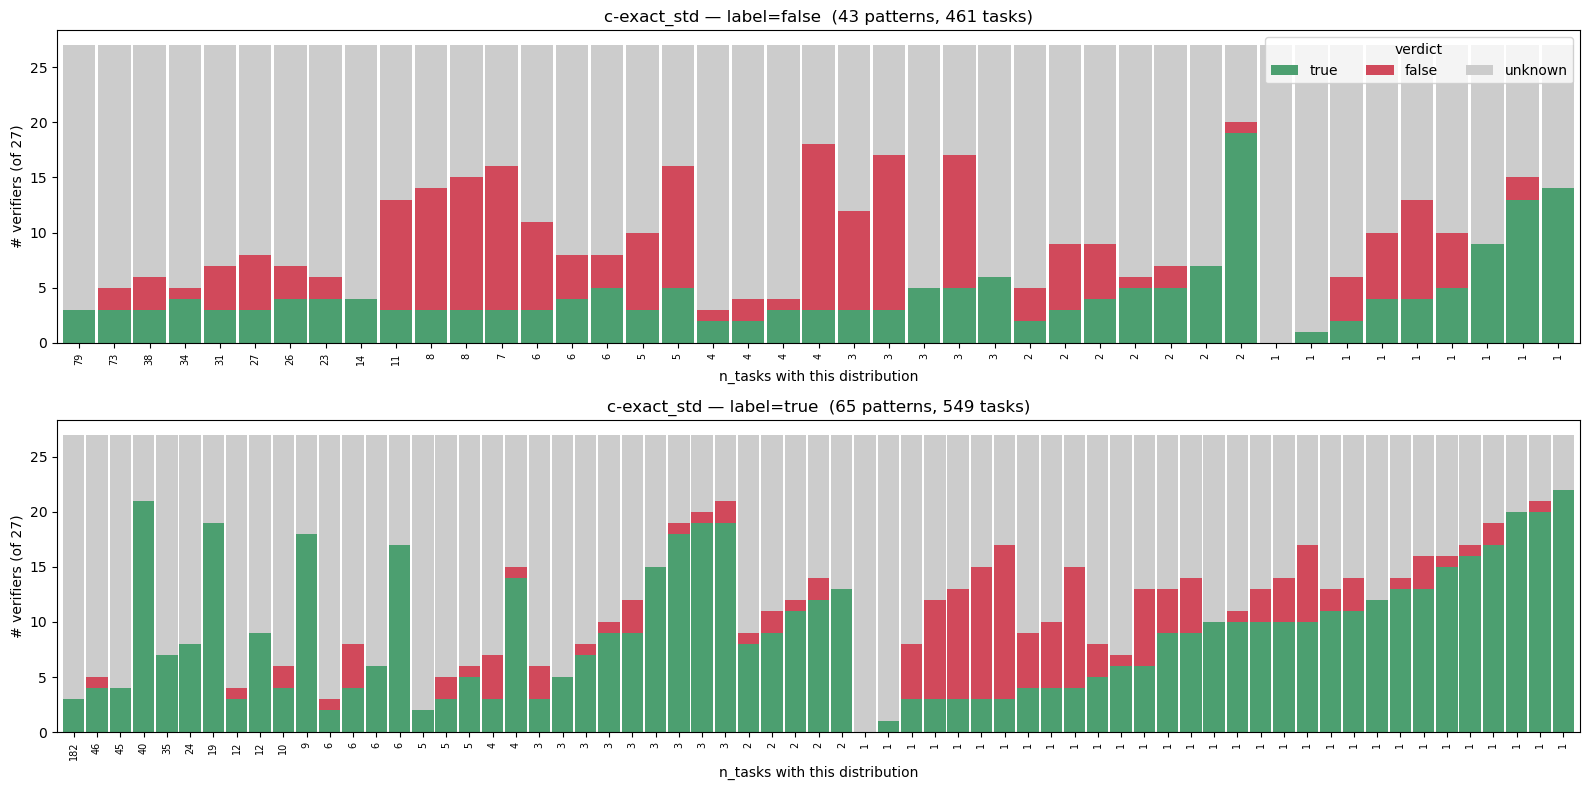

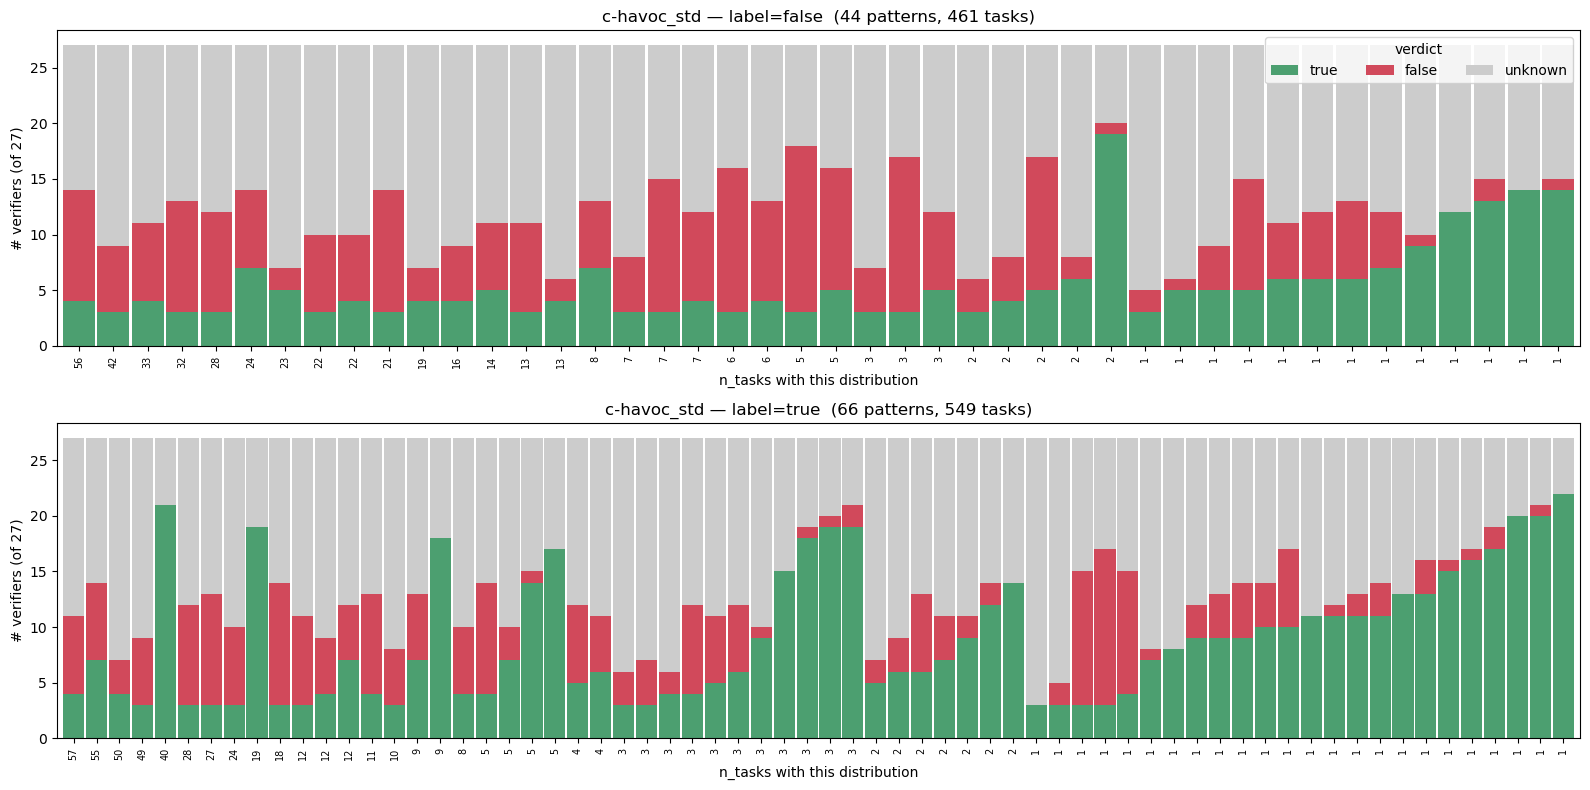

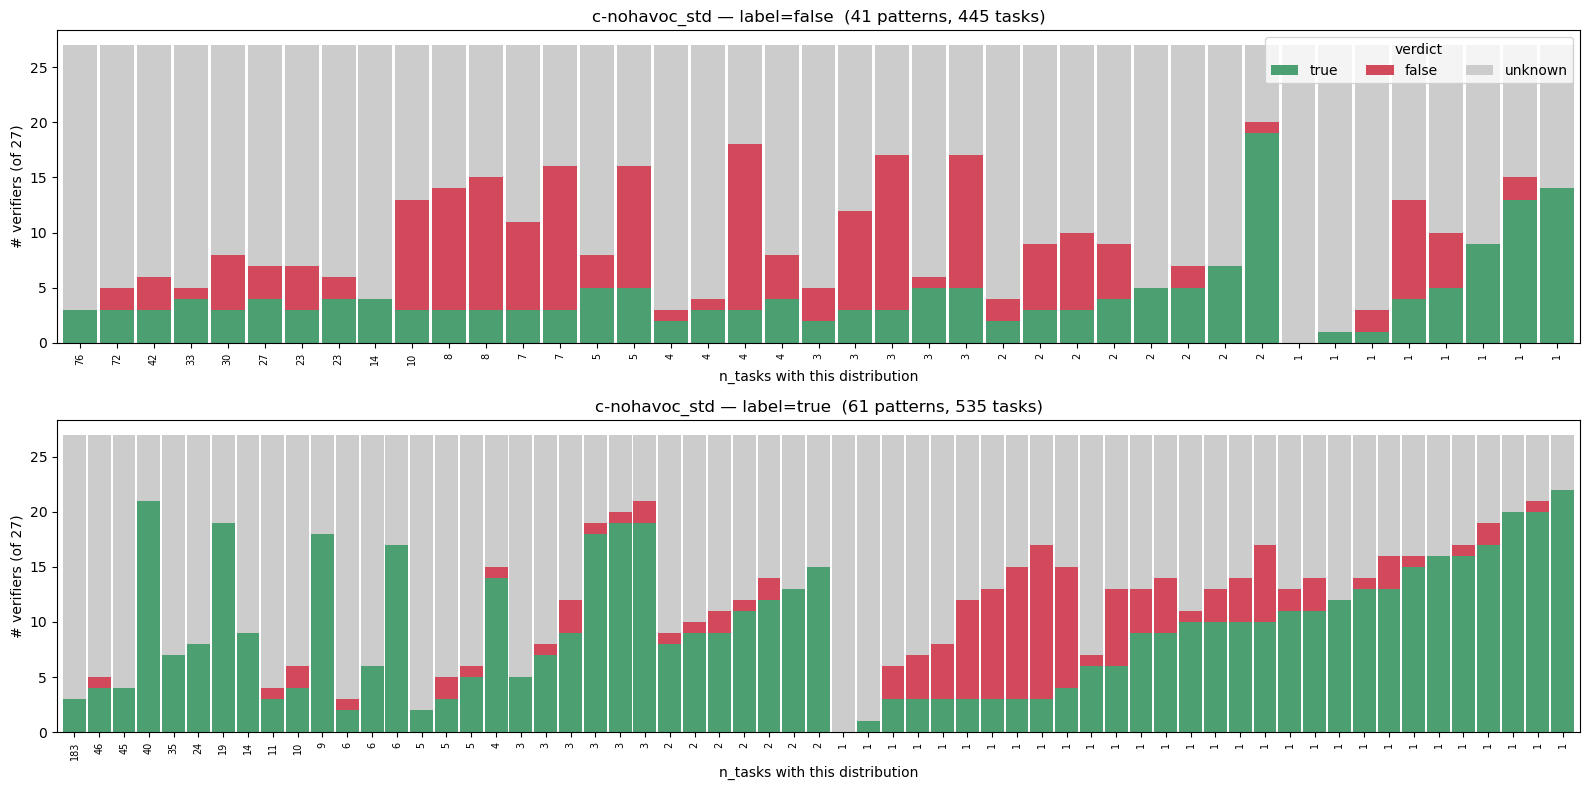

In [94]:
VCOLORS = {"true": "#4C9F70", "false": "#D1495B", "unknown": "#CCCCCC"}


def plot_patterns(cfg: str, tbl: pd.DataFrame | None = None):
    tbl = agreement[cfg] if tbl is None else tbl   # (label, true, false, unknown, n_tasks)
    n_ver = int(tbl[["true", "false", "unknown"]].sum(axis=1).max())  # verifiers per task
    labels = list(tbl.label.unique())
    fig, axes = plt.subplots(len(labels), 1, figsize=(16, 4 * len(labels)), squeeze=False)
    for ax, lab in zip(axes[:, 0], labels):
        d = (tbl[tbl.label == lab]
             .sort_values("n_tasks", ascending=False).reset_index(drop=True))
        x = range(len(d))
        bottom = np.zeros(len(d))
        for v in ("true", "false", "unknown"):
            ax.bar(x, d[v], bottom=bottom, width=0.92, color=VCOLORS[v], label=v)
            bottom += d[v].to_numpy()
        ax.set_xticks(list(x))
        ax.set_xticklabels(d.n_tasks, rotation=90, fontsize=7)
        ax.set_xlabel("n_tasks with this distribution")
        ax.set_ylabel(f"# verifiers (of {n_ver})")
        ax.set_title(f"{cfg} — label={lab}  "
                     f"({len(d)} patterns, {d.n_tasks.sum()} tasks)")
        ax.margins(x=0.004)
    axes[0, 0].legend(title="verdict", ncol=3, loc="upper right")
    fig.tight_layout()
    return fig


for cfg in MAPPED_CONFIGS:
    export_fig(plot_patterns(cfg), "rq2", f"pattern_{cfg}",
               f"Distribution of verifier-agreement patterns on \\texttt{{{cfg}}}, "
               f"faceted by ground-truth label; bars sorted by task count.",
               label=f"fig:pattern-{cfg}")


## C++ comparison: the same views on the original suite

The same majority / unanimous tables and stacked-bar plot for the original C++ suite(s).
`cbmc` is excluded as a native-C++ verifier (it solves only a fragment of the suite),
leaving `divine` and `esbmc-kind` — so the votes here are out of 2, not out of the full
set of retained mapped-C verifiers.


===== cpp-baseline (1094 tasks, 2 verifiers) =====


majority,false,tie,true,unknown
label,,,,
false,411,9,52,40
true,12,21,546,3


unanimous,all-false,all-true,conflict,none
label,,,,
false,411,52,9,40
true,12,546,21,3


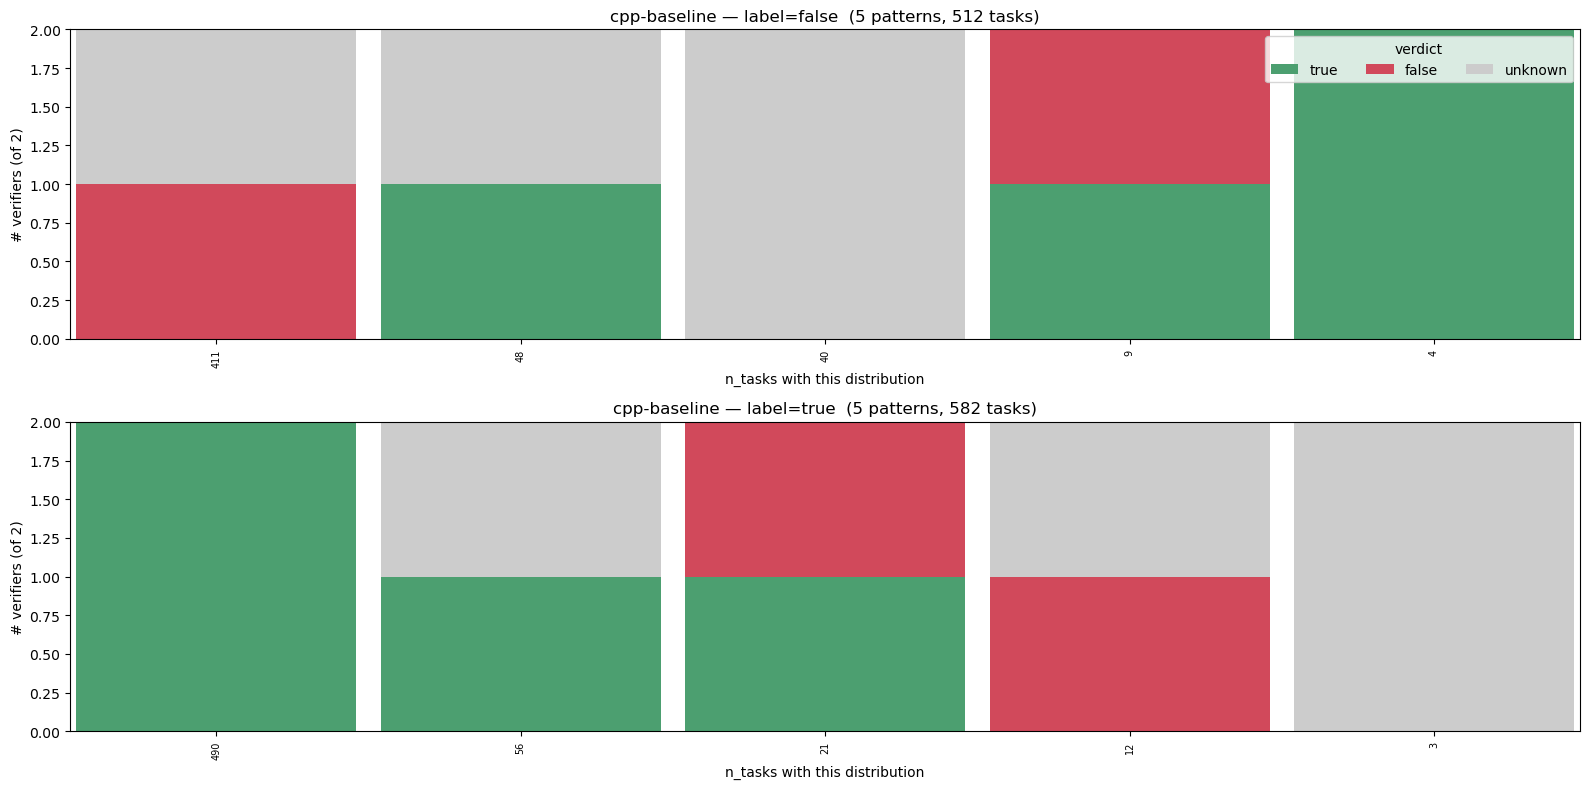

In [95]:
for cfg in ORIGINAL_CONFIGS:
    pt = collapse(per_task_counts(cfg), min_votes_for(cfg))
    n_ver = df[df.config == cfg].tool.nunique()
    print(f"\n===== {cfg} ({len(pt)} tasks, {n_ver} verifiers) =====")
    maj = pd.crosstab(pt.label, pt.majority).rename_axis(columns="majority")
    una = pd.crosstab(pt.label, pt.unanimous).rename_axis(columns="unanimous")
    display(export_table(maj, "rq2", f"majority_{cfg}",
                         f"Per-task majority verdict vs.\\ ground-truth label on the "
                         f"original C++ suite \\texttt{{{cfg}}}.",
                         label=f"tab:majority-{cfg}"))
    display(export_table(una, "rq2", f"unanimous_{cfg}",
                         f"Per-task unanimity vs.\\ ground-truth label on the original "
                         f"C++ suite \\texttt{{{cfg}}}.",
                         label=f"tab:unanimous-{cfg}"))
    export_fig(plot_patterns(cfg, agreement_table(cfg)), "rq2", f"pattern_{cfg}",
               f"Distribution of verifier-agreement patterns on the original C++ suite "
               f"\\texttt{{{cfg}}}.",
               label=f"fig:pattern-{cfg}")


### C++ majority ties: who voted what

For every tie task on the original C++ suite, the per-verifier verdict (`divine` /
`esbmc-kind`; `cbmc` excluded).


In [96]:
for cfg in ORIGINAL_CONFIGS:
    pt = collapse(per_task_counts(cfg), min_votes_for(cfg))
    tie_tasks = pt.loc[pt.majority == "tie", "task"]
    votes = (
        df[(df.config == cfg) & (df.task.isin(tie_tasks))]
        .pivot_table(index="task", columns="tool", values="verdict", aggfunc="first")
    )
    print(f"{cfg}: {len(tie_tasks)} tie tasks")
    display(votes)


cpp-baseline: 30 tie tasks


tool,divine,esbmc-kind
task,,
algorithm/algorithm57/algorithm_algorithm57.yml,true,false
algorithm/algorithm58/algorithm_algorithm58.yml,true,false
algorithm/algorithm69_adjacent_find1/algorithm_algorithm69_adjacent_find1.yml,true,false
algorithm/algorithm70/algorithm_algorithm70.yml,true,false
cbmc/Templates6/cbmc_Templates6.yml,true,false
deque/deque_erase/deque_deque_erase.yml,true,false
gcc-template-tests/ctor2/gcc-template-tests_ctor2.yml,true,false
inheritance_bringup/inheritance09/inheritance_bringup_inheritance09.yml,true,false
list/list_insert/list_list_insert.yml,true,false


## Dual majority: C++ vs C (mapped)

Join each mapped suite to the original C++ suite on the shared tasks, and cross the two
majority verdicts. The diagonal is agreement between the C++ and the mapped-C consensus;
off-diagonal cells are where mapping flipped (or lost) the consensus. The heatmap shows
how those `(C++ majority, C majority)` combinations are distributed. Next to it, the same
shared tasks are crossed against the ground-truth `label` instead of the C++ majority, i.e.
`(label, C majority)`, for a direct soundness read independent of the (only-2-verifier)
C++ consensus.


===== cpp-baseline (C++) vs c-exact_std: 1010 shared tasks =====


<>:40: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:40: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
/tmp/ipykernel_36361/2876265857.py:40: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
  """Two heatmaps side by side: C++ majority vs.\ C majority, and label vs.\ C majority."""


c_majority,true,false,tie,unknown
cpp_majority,,,,
true,534,15,9,3
false,237,122,46,1
tie,25,4,1,0
unknown,9,2,2,0


c_majority,true,false,tie,unknown
label,,,,
true,525,13,9,2
false,280,130,49,2


c_majority          false  tie  true  unknown
label cpp_majority                           
false false           121   45   229        1
      tie               1    1     7        0
      true              6    1    37        1
      unknown           2    2     7        0
true  false             1    1     8        0
      tie               3    0    18        0
      true              9    8   497        2
      unknown           0    0     2        0

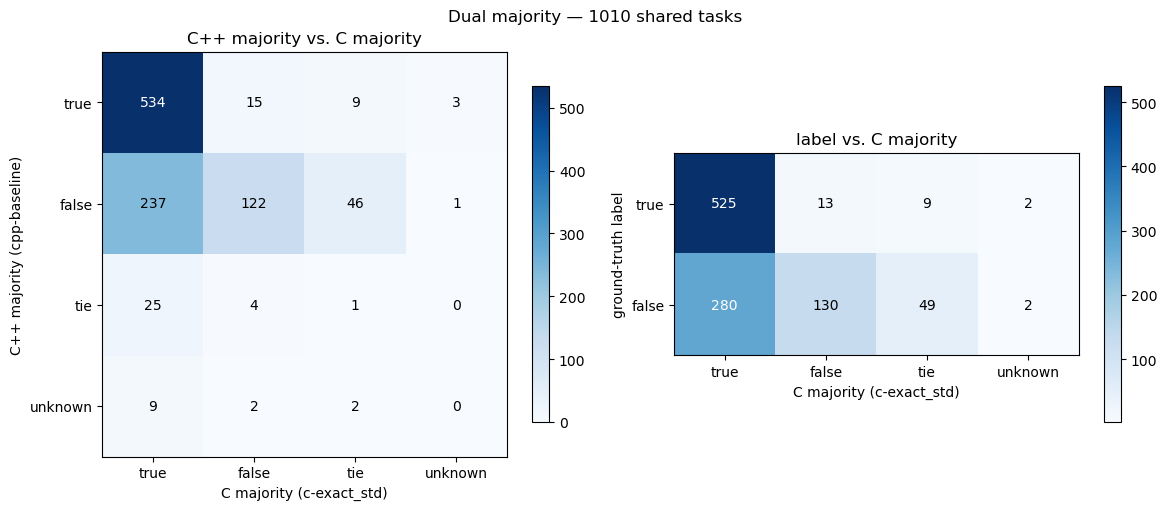


===== cpp-baseline (C++) vs c-havoc_std: 1010 shared tasks =====


c_majority,true,false,tie,unknown
cpp_majority,,,,
true,212,294,55,0
false,66,313,27,0
tie,6,16,8,0
unknown,2,11,0,0


c_majority,true,false,tie,unknown
label,,,,
true,209,279,61,0
false,77,355,29,0


c_majority          false  tie  true
label cpp_majority                  
false false           307   25    64
      tie               5    3     1
      true             32    1    12
      unknown          11    0     0
true  false             6    2     2
      tie              11    5     5
      true            262   54   200
      unknown           0    0     2

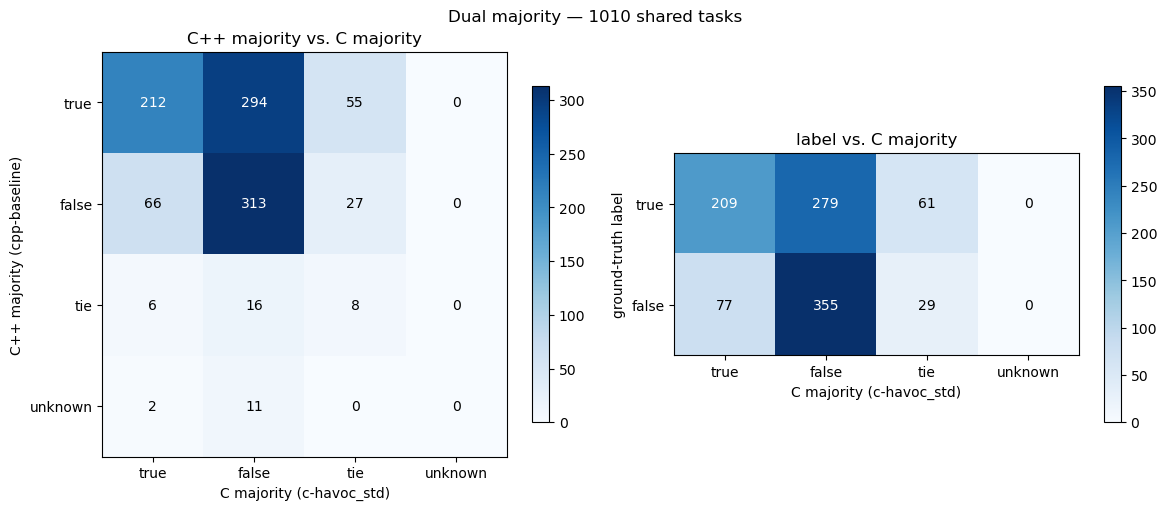


===== cpp-baseline (C++) vs c-nohavoc_std: 980 shared tasks =====


c_majority,true,false,tie,unknown
cpp_majority,,,,
true,530,12,2,3
false,232,115,45,1
tie,25,1,1,0
unknown,9,2,2,0


c_majority,true,false,tie,unknown
label,,,,
true,524,8,1,2
false,272,122,49,2


c_majority          false  tie  true  unknown
label cpp_majority                           
false false           114   45   224        1
      tie               0    1     7        0
      true              6    1    34        1
      unknown           2    2     7        0
true  false             1    0     8        0
      tie               1    0    18        0
      true              6    1   496        2
      unknown           0    0     2        0

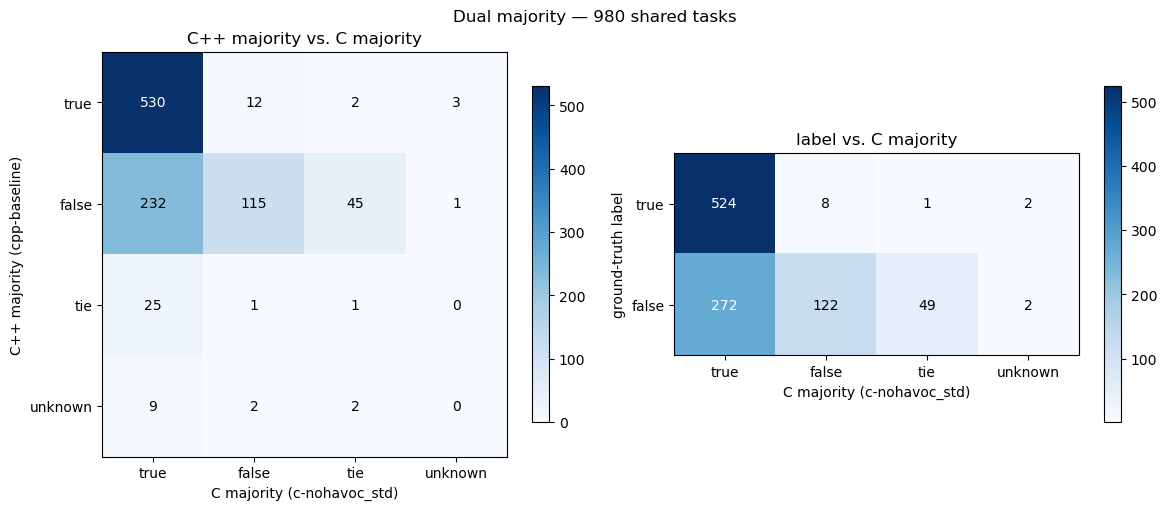

In [97]:
MAJ_ORDER = ["true", "false", "tie", "unknown"]
CPP_REF = ORIGINAL_CONFIGS[0]  # original C++ suite used as the reference


def dual_majority(c_cfg: str, cpp_cfg: str = CPP_REF) -> pd.DataFrame:
    """Per-task C++ vs mapped-C majority, joined on the shared tasks (and label)."""
    def m(cfg, col):
        return (collapse(per_task_counts(cfg), min_votes_for(cfg))[["task", "label", "majority"]]
                .rename(columns={"majority": col}))
    return m(cpp_cfg, "cpp_majority").merge(m(c_cfg, "c_majority"), on=["task", "label"])


def dual_crosstab(dm: pd.DataFrame) -> pd.DataFrame:
    return (pd.crosstab(dm.cpp_majority, dm.c_majority)
            .reindex(index=MAJ_ORDER, columns=MAJ_ORDER, fill_value=0))


def label_crosstab(dm: pd.DataFrame) -> pd.DataFrame:
    """Ground-truth label vs. mapped-C majority, over the same shared tasks as dual_crosstab."""
    return (pd.crosstab(dm.label, dm.c_majority)
            .reindex(index=["true", "false"], columns=MAJ_ORDER, fill_value=0))


def _draw_heatmap(ax, ct: pd.DataFrame, ylabel: str, title: str):
    im = ax.imshow(ct.values, cmap="Blues")
    ax.set_xticks(range(len(MAJ_ORDER)), MAJ_ORDER)
    ax.set_yticks(range(len(ct.index)), ct.index)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    hi = ct.values.max() if ct.values.size else 0
    for i in range(len(ct.index)):
        for j in range(len(MAJ_ORDER)):
            v = ct.values[i, j]
            ax.text(j, i, int(v), ha="center", va="center",
                    color="white" if hi and v > hi / 2 else "black")
    return im


def plot_dual(ct_cpp: pd.DataFrame, ct_label: pd.DataFrame, c_cfg: str, n: int):
    """Two heatmaps side by side: C++ majority vs.\ C majority, and label vs.\ C majority."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    im0 = _draw_heatmap(axes[0], ct_cpp, f"C++ majority ({CPP_REF})", "C++ majority vs. C majority")
    im1 = _draw_heatmap(axes[1], ct_label, "ground-truth label", "label vs. C majority")
    for ax in axes:
        ax.set_xlabel(f"C majority ({c_cfg})")
    fig.colorbar(im0, ax=axes[0], shrink=0.8)
    fig.colorbar(im1, ax=axes[1], shrink=0.8)
    fig.suptitle(f"Dual majority — {n} shared tasks")
    fig.tight_layout()
    return fig


for c_cfg in MAPPED_CONFIGS:
    dm = dual_majority(c_cfg)
    ct = dual_crosstab(dm)
    ct_label = label_crosstab(dm)
    print(f"\n===== {CPP_REF} (C++) vs {c_cfg}: {len(dm)} shared tasks =====")
    display(export_table(ct, "rq2", f"dual_majority_{c_cfg}",
                         f"Majority verdict on the original C++ suite (rows) vs.\\ on "
                         f"\\texttt{{{c_cfg}}} (columns), over the {len(dm)} shared tasks.",
                         label=f"tab:dual-majority-{c_cfg}"))
    display(export_table(ct_label, "rq2", f"label_majority_{c_cfg}",
                         f"Ground-truth label (rows) vs.\\ majority verdict on "
                         f"\\texttt{{{c_cfg}}} (columns), over the same {len(dm)} shared tasks.",
                         label=f"tab:label-majority-{c_cfg}"))
    display(pd.crosstab([dm.label, dm.cpp_majority], dm.c_majority))  # label-split, inline only
    export_fig(plot_dual(ct, ct_label, c_cfg, len(dm)), "rq2", f"dual_majority_{c_cfg}_heatmap",
               f"Distribution of (C++, \\texttt{{{c_cfg}}}) majority-verdict combinations "
               f"(left) and (ground-truth label, \\texttt{{{c_cfg}}}) majority-verdict "
               f"combinations (right), over the {len(dm)} shared tasks.",
               label=f"fig:dual-majority-{c_cfg}", width=r"\linewidth")

## Self-consistency: same tool, C++ vs mapped

For each native-C++ verifier (`divine`, `esbmc-kind`), compare *its own* verdict on the
C++ original against its verdict on the same task's mapped-C version, over the shared
tasks — a single tool, two inputs, so no cross-tool confounding. The crosstab (rows =
C++ verdict, columns = mapped-C verdict) shows every distinct `(C++, mapped)` verdict
pair and its frequency: the diagonal is self-agreement, and the `true`↔`false`
off-diagonals are the soundness-relevant flips introduced by the mapping.


In [98]:
# Verifiers that ran both a C++ suite and the mapped suites (cbmc already dropped from C++).
NATIVE_BOTH = [t for t in sorted(df.loc[df.config.isin(ORIGINAL_CONFIGS), "tool"].unique())
               if t in set(df.loc[df.config.isin(MAPPED_CONFIGS), "tool"])]
VORDER = ["true", "false", "unknown"]


def self_pairs(tool, c_cfg, cpp_cfg=CPP_REF):
    """One row per shared task: the tool's C++ verdict (cpp) and mapped-C verdict (c)."""
    a = (df[(df.tool == tool) & (df.config == cpp_cfg)][["task", "verdict"]]
         .rename(columns={"verdict": "cpp"}))
    b = (df[(df.tool == tool) & (df.config == c_cfg)][["task", "verdict"]]
         .rename(columns={"verdict": "c"}))
    return a.merge(b, on="task")


def pair_bucket(cpp, c):
    if cpp == c:
        return "same"
    if c == "unknown":
        return "lost (C++→unknown)"
    if cpp == "unknown":
        return "gained (unknown→C)"
    return "conflict (true↔false)"


rows, buckets = [], {}
for c_cfg in MAPPED_CONFIGS:
    for tool in NATIVE_BOTH:
        m = self_pairs(tool, c_cfg)
        ct = pd.crosstab(m.cpp, m.c).reindex(index=VORDER, columns=VORDER, fill_value=0)
        n, agree = len(m), int(np.diag(ct.values).sum())
        conflict = int(ct.loc["true", "false"] + ct.loc["false", "true"])
        print(f"\n=== {tool}: C++ vs {c_cfg}  ({n} shared tasks) ===")
        display(export_table(ct, "rq2", f"selfpair_{tool}_{c_cfg}",
                f"Self-consistency of \\texttt{{{tool}}}: verdict on the C++ original "
                f"(rows) vs.\\ on \\texttt{{{c_cfg}}} (columns), over {n} shared tasks.",
                label=f"tab:selfpair-{tool}-{c_cfg}"))
        buckets[(tool, c_cfg)] = m.apply(lambda r: pair_bucket(r.cpp, r.c), axis=1).value_counts()
        rows.append(dict(suite=c_cfg, tool=tool, shared=n, agree=agree,
                         agree_pct=round(100 * agree / n, 1), conflict=conflict,
                         distinct_pairs=int((ct.values > 0).sum())))

selfpair_summary = pd.DataFrame(rows).set_index(["suite", "tool"])
display(export_table(selfpair_summary, "rq2", "selfpair_summary",
        "Per-tool self-consistency between the C++ original and each mapped suite: shared "
        "tasks, identical-verdict count and rate, true/false conflicts, and number of "
        "distinct (C++, mapped) verdict pairs.",
        label="tab:selfpair-summary"))



=== divine: C++ vs c-exact_std  (1010 shared tasks) ===


c,true,false,unknown
cpp,,,
true,198,12,319
false,0,0,0
unknown,8,145,328



=== esbmc-kind: C++ vs c-exact_std  (1010 shared tasks) ===


c,true,false,unknown
cpp,,,
true,169,19,357
false,27,118,291
unknown,5,2,22



=== divine: C++ vs c-havoc_std  (1010 shared tasks) ===


...


=== divine: C++ vs c-nohavoc_std  (980 shared tasks) ===


c,true,false,unknown
cpp,,,
true,196,12,313
false,0,0,0
unknown,7,144,308



=== esbmc-kind: C++ vs c-nohavoc_std  (980 shared tasks) ===


c,true,false,unknown
cpp,,,
true,168,18,345
false,25,112,283
unknown,5,2,22


shared  agree  agree_pct  conflict  distinct_pairs
suite         tool                                                          
c-exact_std   divine        1010    526       52.1        12               6
              esbmc-kind    1010    309       30.6        46               9
c-havoc_std   divine        1010    223       22.1       341               6
              esbmc-kind    1010    535       53.0       446               8
c-nohavoc_std divine         980    504       51.4        12               6
              esbmc-kind     980    302       30.8        43               9

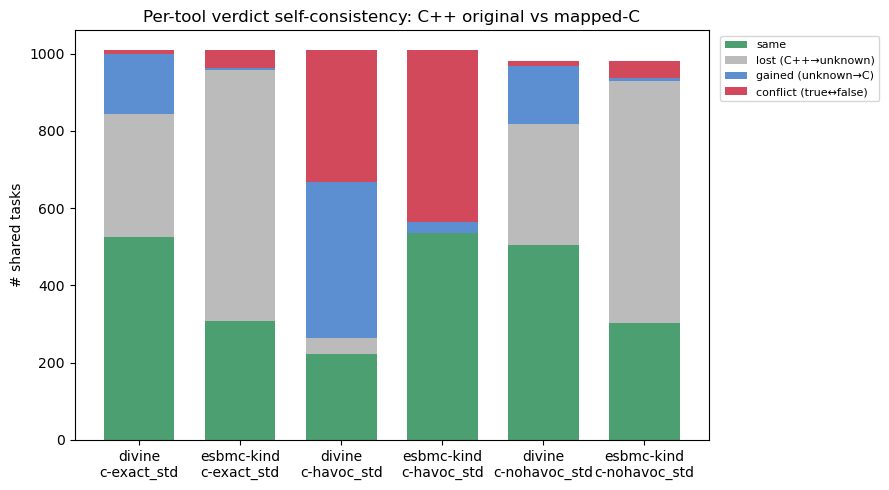

In [99]:
BUCKET_ORDER = ["same", "lost (C++→unknown)", "gained (unknown→C)", "conflict (true↔false)"]
BUCKET_COLORS = {"same": "#4C9F70", "lost (C++→unknown)": "#BBBBBB",
                 "gained (unknown→C)": "#5B8FD1", "conflict (true↔false)": "#D1495B"}

bdf = pd.DataFrame(buckets).T.reindex(columns=BUCKET_ORDER).fillna(0).astype(int)
labels = [f"{tool}\n{cfg}" for tool, cfg in bdf.index]

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(bdf))
for bk in BUCKET_ORDER:
    ax.bar(range(len(bdf)), bdf[bk], bottom=bottom, color=BUCKET_COLORS[bk], label=bk, width=0.7)
    bottom += bdf[bk].to_numpy()
ax.set_xticks(range(len(bdf)), labels)
ax.set_ylabel("# shared tasks")
ax.set_title("Per-tool verdict self-consistency: C++ original vs mapped-C")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))
fig.tight_layout()
export_fig(fig, "rq2", "selfpair_buckets",
           "Per-tool agreement between a verifier's verdict on the C++ original and on its "
           "mapped-C version, over shared tasks: identical, lost to unknown, gained from "
           "unknown, or a true/false conflict.",
           label="fig:selfpair-buckets")


# RQ3 — Performance: CPU time & memory

Resource usage per task suite, treated separately for now (no cross-suite pairing yet).
CPU time is in seconds (timeouts land at ~900 s); memory is in GB. Note these are *all*
runs across the retained verifiers, so the distributions mix fast error-exits, real
solves, and timeouts — split by outcome later if needed.


In [100]:
res = df.assign(
    mem_gb=df.memory / 1e9,
    timeout=df.status.str.contains("TIMEOUT", na=False),
)

# Per-suite resource summary.
perf = (
    res.groupby("config", observed=True)
    .agg(
        runs=("cputime", "size"),
        timeouts=("timeout", "sum"),
        cpu_median_s=("cputime", "median"),
        cpu_p90_s=("cputime", lambda s: s.quantile(0.9)),
        cpu_max_s=("cputime", "max"),
        cpu_total_h=("cputime", lambda s: s.sum() / 3600),
        mem_median_gb=("mem_gb", "median"),
        mem_p90_gb=("mem_gb", lambda s: s.quantile(0.9)),
        mem_max_gb=("mem_gb", "max"),
    )
    .round(3)
)
display(export_table(perf, "rq3", "perf_summary",
                     "CPU time and memory per task suite (all retained verifiers, all "
                     "runs). Times in seconds, memory in GB.",
                     label="tab:perf-summary"))

# Per-verifier medians within each suite.
cpu_by_tool = res.pivot_table(index="tool", columns="config", values="cputime",
                              aggfunc="median", observed=False).round(2)
mem_by_tool = res.pivot_table(index="tool", columns="config", values="mem_gb",
                              aggfunc="median", observed=False).round(3)
print("Median CPU time (s) per verifier × suite:")
display(export_table(cpu_by_tool, "rq3", "cpu_median_by_tool",
                     "Median CPU time (s) per verifier and task suite.",
                     label="tab:cpu-median-by-tool"))
print("Median memory (GB) per verifier × suite:")
display(export_table(mem_by_tool, "rq3", "mem_median_by_tool",
                     "Median memory (GB) per verifier and task suite.",
                     label="tab:mem-median-by-tool"))


,runs,timeouts,cpu_median_s,cpu_p90_s,cpu_max_s,cpu_total_h,mem_median_gb,mem_p90_gb,mem_max_gb
config,,,,,,,,,
cpp-baseline,2188,22,5.469,25.929,902.054,13.237,0.202,0.495,15.0
c-exact_std,27270,6050,8.129,900.888,903.988,1819.827,0.215,4.184,15.0
c-havoc_std,27270,1613,2.107,205.128,903.191,599.725,0.099,0.762,15.0
c-nohavoc_std,26460,5944,8.347,900.899,905.050,1782.747,0.220,4.246,15.0


Median CPU time (s) per verifier × suite:


config,cpp-baseline,c-exact_std,c-havoc_std,c-nohavoc_std
tool,,,,
2ls,NaN,0.23,0.11,0.23
bubaak,NaN,2.00,1.35,2.00
bubaak-split,NaN,7.88,1.99,8.03
cbmc,NaN,0.24,0.12,0.24
cpachecker,NaN,47.45,7.21,55.22
crux,NaN,1.02,0.17,1.05
divine,16.17,5.98,16.46,5.97
emergentheta,NaN,5.37,10.63,5.41
esbmc-kind,1.51,48.12,0.39,52.17


Median memory (GB) per verifier × suite:


config,cpp-baseline,c-exact_std,c-havoc_std,c-nohavoc_std
tool,,,,
2ls,NaN,0.015,0.005,0.015
bubaak,NaN,0.091,0.041,0.092
bubaak-split,NaN,0.114,0.061,0.118
cbmc,NaN,0.015,0.006,0.015
cpachecker,NaN,0.431,0.186,0.457
crux,NaN,0.066,0.019,0.067
divine,0.368,0.302,0.570,0.302
emergentheta,NaN,0.206,0.480,0.210
esbmc-kind,0.114,0.278,0.048,0.285


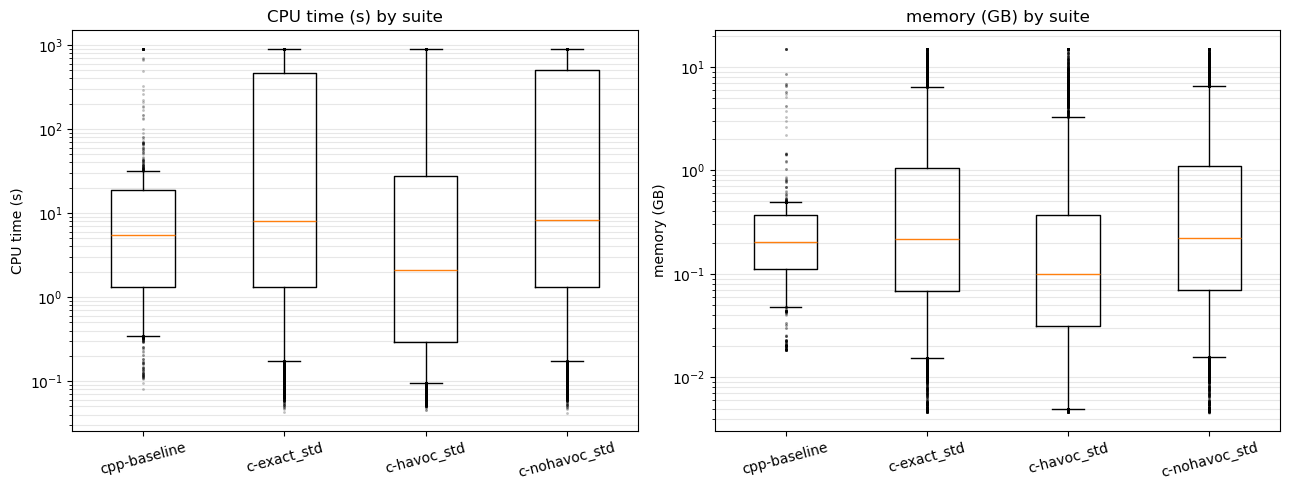

In [101]:
# Distributions per suite (log scale; whiskers at 5th/95th pct, dots are runs beyond).
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (col, lab) in zip(axes, [("cputime", "CPU time (s)"), ("mem_gb", "memory (GB)")]):
    data = [res.loc[res.config == c, col].dropna().to_numpy() for c in CONFIGS]
    ax.boxplot(data, tick_labels=CONFIGS, whis=(5, 95),
               flierprops=dict(marker=".", markersize=2, alpha=0.25))
    ax.set_yscale("log")
    ax.set_ylabel(lab)
    ax.set_title(f"{lab} by suite")
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", which="both", alpha=0.3)
fig.tight_layout()
export_fig(fig, "rq3", "resource_boxplots",
           "CPU time and memory distributions per task suite (log scale; whiskers at the "
           "5th/95th percentile).",
           label="fig:resource-box")


## Quantile (cactus) plots

BenchExec-style: per verifier, take its **correctly solved** tasks (`bx_category ==
"correct"`), sort their CPU times ascending, and plot `x = # solved`, `y = CPU time`
(log). A curve further right solves more tasks; lower means faster. One plot per suite
below, then one over the C/C++ **shared** tasks where the native-C++ verifiers appear
twice — once on the C++ input (dashed), once on the mapped-C input (solid, same colour).


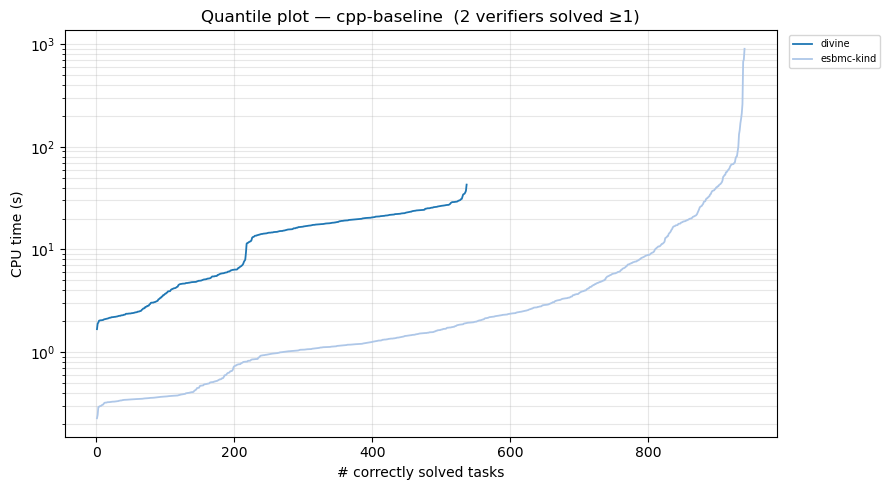

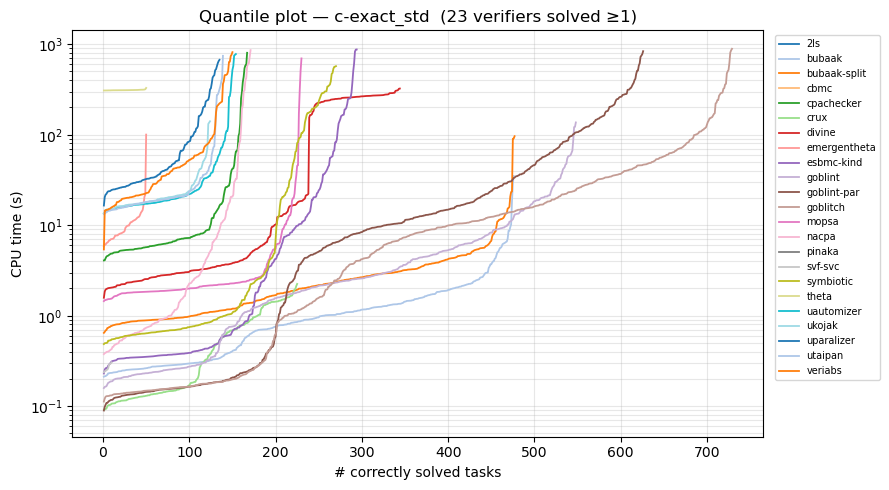

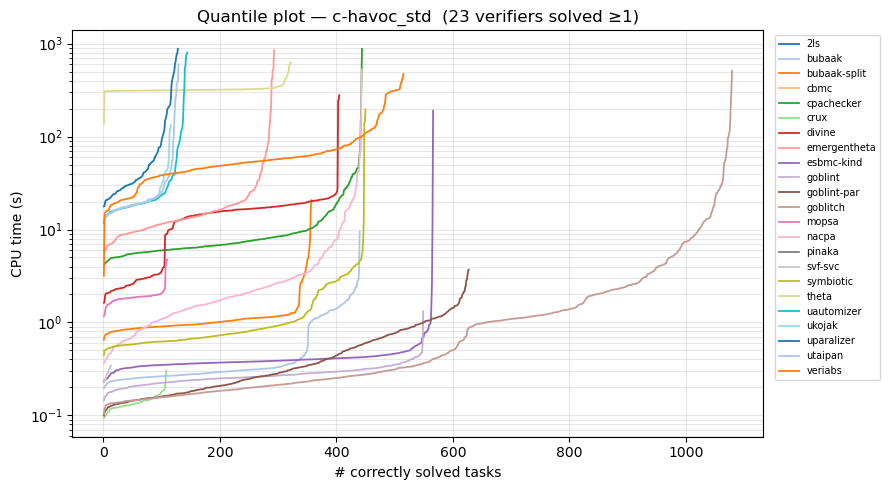

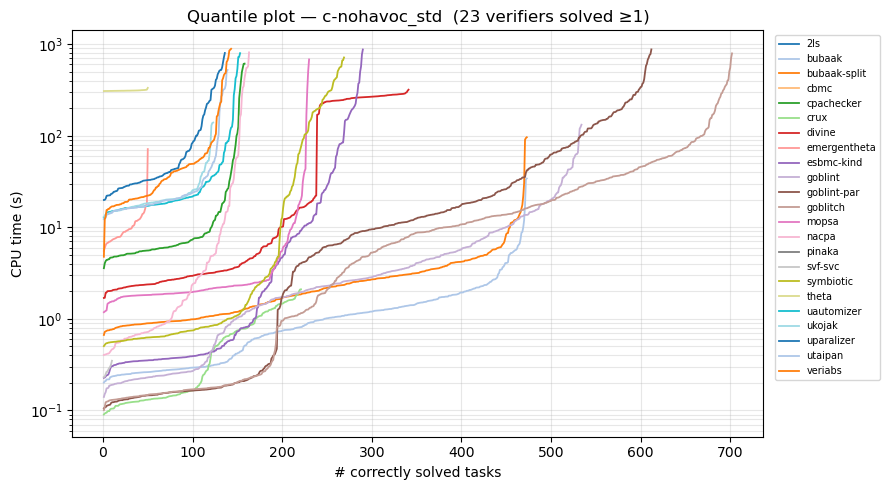

In [102]:
def solved_times(d: pd.DataFrame) -> np.ndarray:
    """Sorted CPU times of correctly-solved runs (BenchExec 'correct')."""
    return d.loc[d.bx_category == "correct", "cputime"].dropna().sort_values().to_numpy()


def quantile_plot(series: dict, ax, title: str):
    """series: label -> sorted cpu-time array. Native-C++ curves ('… (C++)') are dashed
    and share the colour of their mapped-C namesake."""
    bases = list(dict.fromkeys(lbl.replace(" (C++)", "") for lbl in series))
    cmap = plt.get_cmap("tab20")
    color = {b: cmap(i % 20) for i, b in enumerate(bases)}
    for lbl, arr in series.items():
        if len(arr) == 0:
            continue
        ax.plot(range(1, len(arr) + 1), arr, label=lbl,
                color=color[lbl.replace(" (C++)", "")], lw=1.3,
                ls="--" if lbl.endswith("(C++)") else "-")
    ax.set_yscale("log")
    ax.set_xlabel("# correctly solved tasks")
    ax.set_ylabel("CPU time (s)")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=7, ncol=1, loc="upper left", bbox_to_anchor=(1.01, 1.0))


for cfg in CONFIGS:
    sub = df[df.config == cfg]
    series = {t: solved_times(sub[sub.tool == t]) for t in sorted(sub.tool.unique())}
    series = {k: v for k, v in series.items() if len(v)}
    fig, ax = plt.subplots(figsize=(9, 5))
    quantile_plot(series, ax, f"Quantile plot — {cfg}  ({len(series)} verifiers solved ≥1)")
    fig.tight_layout()
    export_fig(fig, "rq3", f"quantile_{cfg}",
               f"Quantile (cactus) plot of CPU time for correctly solved tasks on "
               f"\\texttt{{{cfg}}}; one curve per verifier.",
               label=f"fig:quantile-{cfg}")


### Shared C/C++ tasks — all verifiers, native-C++ ones doubled

One plot per mapped suite, restricted to tasks present in **both** that suite and the
C++ original. Every mapped-C verifier contributes one (solid) curve; the native-C++
verifiers (`divine`, `esbmc-kind`; `cbmc` excluded from the C++ side) contribute a
second, dashed curve from their C++ run, so the mapping cost is visible as the gap
between a tool's solid and dashed lines.


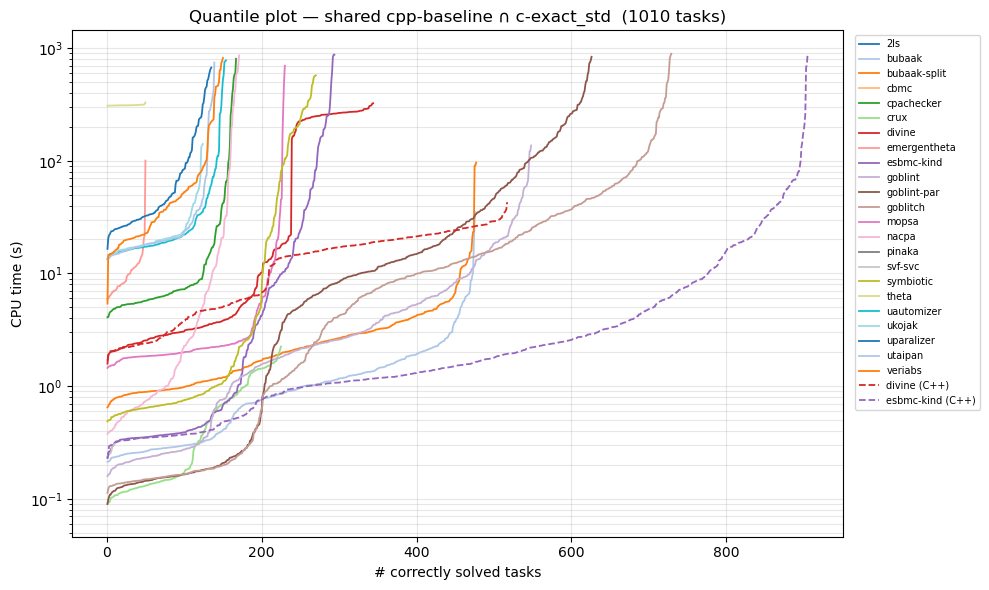

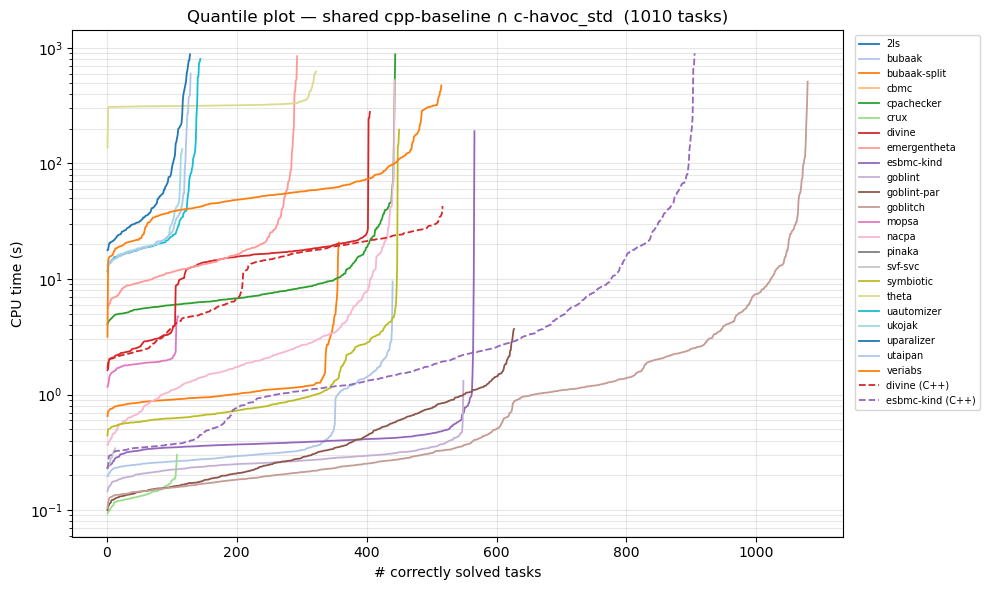

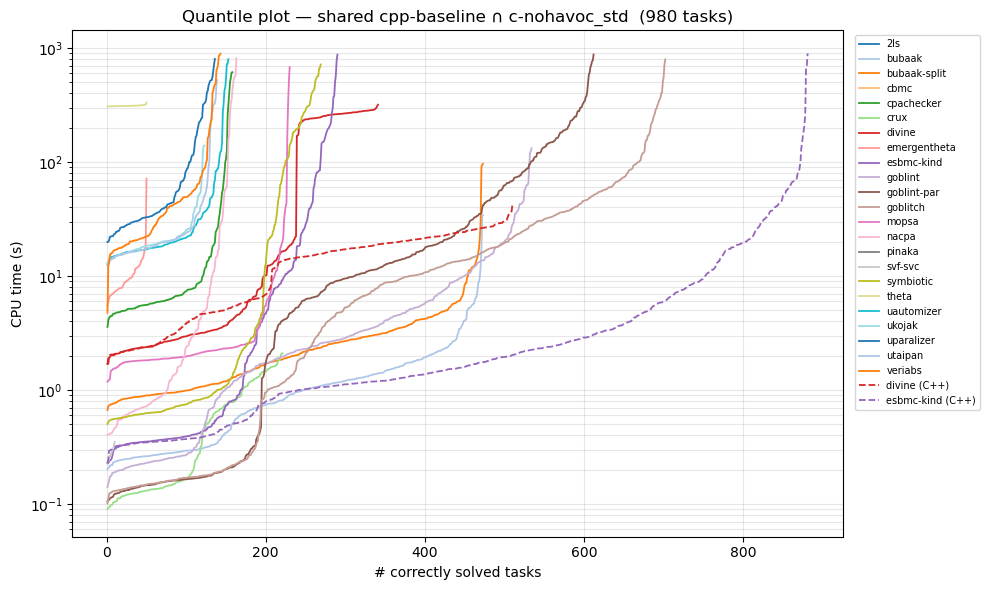

In [103]:
def shared_quantile(c_cfg: str, cpp_cfg: str = CPP_REF):
    """Cactus plot over the tasks shared by cpp_cfg and c_cfg; native-C++ tools doubled."""
    shared = set(df.loc[df.config == cpp_cfg, "task"]) & set(df.loc[df.config == c_cfg, "task"])
    series = {}
    csub = df[(df.config == c_cfg) & (df.task.isin(shared))]
    for t in sorted(csub.tool.unique()):
        series[t] = solved_times(csub[csub.tool == t])             # mapped-C run (solid)
    psub = df[(df.config == cpp_cfg) & (df.task.isin(shared))]
    for t in sorted(psub.tool.unique()):
        series[f"{t} (C++)"] = solved_times(psub[psub.tool == t])  # C++ run (dashed)
    series = {k: v for k, v in series.items() if len(v)}

    fig, ax = plt.subplots(figsize=(10, 6))
    quantile_plot(series, ax, f"Quantile plot — shared {cpp_cfg} ∩ {c_cfg}  ({len(shared)} tasks)")
    fig.tight_layout()
    export_fig(fig, "rq3", f"quantile_shared_{c_cfg}",
               f"Quantile (cactus) plot over the {len(shared)} tasks shared by the C++ "
               f"suite \\texttt{{{cpp_cfg}}} and \\texttt{{{c_cfg}}}. Native-C++ verifiers "
               f"appear twice: dashed = C++ input, solid = mapped-C input (same colour).",
               label=f"fig:quantile-shared-{c_cfg}")


# One shared-task cactus per mapped suite (rename-proof: no suite name hardcoded).
for c_cfg in MAPPED_CONFIGS:
    shared_quantile(c_cfg)


## Unique solves: C vs C++ on shared tasks

On `c-nohavoc_std` (the C side throughout this comparison, chosen because every called
function is defined, so there are no havoc/leftover-`extern` artefacts), over the tasks it
shares with the C++ baseline, how many tasks were *solved* by only one of the two input
representations. *Solved* means a correct verdict from at least one verifier (BenchExec
`correct`, as in the cactus plots). The **C side** is every verifier on `c-nohavoc_std`; the
**C++ side** is the native-C++ verifiers on the baseline (`divine`, `esbmc-kind`; `cbmc`
excluded). `c_only` = some C verifier solved it but no C++ verifier did (the cir2c mapping
enabled a solve); `cpp_only` = some C++ verifier solved it but no verifier on the mapped-C
input did (the mapping lost a solve). `both` / `neither` and the per-side solved totals give
context, and the four buckets partition the shared tasks.

In [104]:
# Unique solves over the shared tasks: did the cir2c mapping enable or lose a solve,
# relative to the native C++ input? "Solved" = a correct verdict from >=1 verifier
# (BenchExec `correct`), matching the cactus plots. C side = all verifiers on C_REF;
# C++ side = the native-C++ verifiers on the baseline (cbmc already excluded). Only
# c-nohavoc_std is used on the C side (every called function defined).
C_REF = "c-nohavoc_std"   # the mapped-C suite used for the C-vs-C++ comparisons


def unique_solves(c_cfg: str = C_REF, cpp_cfg: str = CPP_REF) -> dict:
    shared = set(df.loc[df.config == c_cfg, "task"]) & set(df.loc[df.config == cpp_cfg, "task"])
    c_solved = set(df.loc[(df.config == c_cfg) & (df.bx_category == "correct"), "task"]) & shared
    cpp_solved = set(df.loc[(df.config == cpp_cfg) & (df.bx_category == "correct"), "task"]) & shared
    return {
        "shared": len(shared),
        "c_solved": len(c_solved),
        "cpp_solved": len(cpp_solved),
        "both": len(c_solved & cpp_solved),
        "c_only": len(c_solved - cpp_solved),     # solved via mapped-C, by no C++ verifier
        "cpp_only": len(cpp_solved - c_solved),    # solved natively in C++, by no mapped-C verifier
        "neither": len(shared - c_solved - cpp_solved),
    }


unique = pd.DataFrame({C_REF: unique_solves()}).T
unique.index.name = "suite"
display(export_table(unique, "rq3", "unique_solves",
        f"Unique solves over the tasks \\texttt{{{C_REF}}} shares with the C++ baseline "
        f"(\\texttt{{{CPP_REF}}}). \\emph{{Solved}} = a correct verdict from at least one "
        f"verifier (BenchExec \\texttt{{correct}}). \\emph{{c\\_only}} tasks are solved via "
        f"the cir2c mapping but by no native-C++ verifier; \\emph{{cpp\\_only}} tasks are "
        f"solved natively in C++ but by no verifier on the mapped-C input.",
        label="tab:unique-solves"))

,shared,c_solved,cpp_solved,both,c_only,cpp_only,neither
suite,,,,,,,
c-nohavoc_std,980,881,916,829,52,87,12


### Which verifiers cover the unique solves

A drill-down of the `c_only` / `cpp_only` counts above. Among the shared tasks that **no C++
verifier** solved, how many does each individual C verifier correctly solve, and how many does
it solve that no other C verifier does (`exclusive` = it is the sole C rescuer)? Then the
mirror: among the tasks **no C verifier** solved, how many each native-C++ verifier solves.
*Solved* is still BenchExec `correct` and the C side is still `c-nohavoc_std`. The universes
(C++-unsolved / C-unsolved tasks) include the handful nobody solves, so `solves` is a
verifier's share of the unsolved-by-the-other-language pool, not of the rescued subset alone;
per-verifier `solves` overlap and do not sum to `c_only` / `cpp_only`.

In [105]:
# Drill-down of the unique solves: among the shared tasks that no C++ verifier solved,
# which C verifiers correctly solve them and how many (and how many they alone rescue)?
# Then the mirror over the tasks no C verifier solved. "Solved" = BenchExec `correct`,
# C side = C_REF, both as in the unique-solves cell above.
def _correct_by_tool(cfg: str, universe: set) -> dict:
    """{tool -> set of `universe` tasks it correctly solves on `cfg`}."""
    d = df[(df.config == cfg) & (df.bx_category == "correct") & (df.task.isin(universe))]
    return {t: set(g.task) for t, g in d.groupby("tool")}


def solver_breakdown(cfg: str, universe: set) -> pd.DataFrame:
    """Per verifier on `cfg`: how many `universe` tasks it solves, how many it solves that no
    other verifier on `cfg` does (sole rescuer), and that as a percentage of `universe`."""
    by = _correct_by_tool(cfg, universe)
    rows = {}
    for t, s in by.items():
        others = set().union(*[v for u, v in by.items() if u != t]) if len(by) > 1 else set()
        rows[t] = {"solves": len(s), "exclusive": len(s - others)}
    out = pd.DataFrame(rows).T
    out["pct_of_universe"] = (100 * out["solves"] / max(len(universe), 1)).round(1)
    return out.sort_values(["solves", "exclusive"], ascending=False)


shared = set(df.loc[df.config == C_REF, "task"]) & set(df.loc[df.config == CPP_REF, "task"])
cpp_solved = set(df.loc[(df.config == CPP_REF) & (df.bx_category == "correct"), "task"]) & shared
c_solved = set(df.loc[(df.config == C_REF) & (df.bx_category == "correct"), "task"]) & shared
cpp_unsolved = shared - cpp_solved     # no C++ verifier solved these (c_only tasks + the unsolved)
c_unsolved = shared - c_solved         # no C verifier solved these (cpp_only tasks + the unsolved)

print(f"Shared {len(shared)} | not solved by any C++ verifier: {len(cpp_unsolved)} "
      f"({len(cpp_unsolved & c_solved)} rescued by some C verifier, {len(cpp_unsolved - c_solved)} "
      f"by none) | not solved by any C verifier: {len(c_unsolved)} "
      f"({len(c_unsolved & cpp_solved)} rescued by some C++ verifier, {len(c_unsolved - cpp_solved)} by none)")

print(f"\nC verifiers on the {len(cpp_unsolved)} tasks no C++ verifier solved:")
display(export_table(solver_breakdown(C_REF, cpp_unsolved), "rq3", "unique_c_breakdown",
        f"For the {len(cpp_unsolved)} \\texttt{{{C_REF}}} tasks (shared with \\texttt{{{CPP_REF}}}) "
        f"that no native-C++ verifier solved, how many each C verifier correctly solves "
        f"(\\emph{{solves}}), how many it alone among C verifiers solves (\\emph{{exclusive}}), and "
        f"that as a percentage of the {len(cpp_unsolved)}.",
        label="tab:unique-c-breakdown"))

print(f"\nC++ verifiers on the {len(c_unsolved)} tasks no C verifier solved:")
display(export_table(solver_breakdown(CPP_REF, c_unsolved), "rq3", "unique_cpp_breakdown",
        f"For the {len(c_unsolved)} shared tasks that no verifier on \\texttt{{{C_REF}}} solved, "
        f"how many each native-C++ verifier correctly solves on the C++ baseline.",
        label="tab:unique-cpp-breakdown"))

Shared 980 | not solved by any C++ verifier: 64 (52 rescued by some C verifier, 12 by none) | not solved by any C verifier: 99 (87 rescued by some C++ verifier, 12 by none)

C verifiers on the 64 tasks no C++ verifier solved:


,solves,exclusive,pct_of_universe
bubaak,34,0,53.1
bubaak-split,34,0,53.1
divine,16,0,25.0
goblitch,15,0,23.4
crux,12,5,18.8
goblint,11,0,17.2
goblint-par,11,0,17.2
esbmc-kind,8,0,12.5
symbiotic,5,0,7.8
mopsa,3,0,4.7



C++ verifiers on the 99 tasks no C verifier solved:


,solves,exclusive,pct_of_universe
esbmc-kind,87,86,87.9
divine,1,0,1.0


### What C verifiers do on the C++ verifiers' wrong tasks

Take each native-C++ verifier's *wrong* C++ verdicts (the `wrong` rows from the C++-vs-labels
sanity check) and look at the same tasks' mapped-C version (`c-nohavoc_std`): does running the C
verifiers on the cir2c output recover the answer the C++ tool got wrong? For each verifier, the
summary counts — over its wrong tasks present in `c-nohavoc_std` (`wrong_in_C`) — how many have
at least one C verifier correct (`c_any_correct`), a correct C majority (`c_majority_correct` =
more C verifiers correct than wrong), at least one C verifier also wrong (`c_any_wrong`), or no C
verifier deciding (`c_all_unknown`). The per-task tables below show, for every such task, the
ground-truth `label` and how the 24 C verifiers split into correct / wrong / unknown.

In [106]:
# Take each native-C++ verifier's *wrong* C++ verdicts and see what the C verifiers do on the
# same tasks' mapped-C version (C_REF): does running C verifiers on the cir2c output recover the
# answer the C++ tool got wrong? "wrong"/"correct" are BenchExec categories; per task we split
# the C verifiers into correct / wrong / unknown (unknown folds in error). Wrong tasks not in
# C_REF are dropped (the gap between wrong_on_cpp and wrong_in_C).
def c_on_cpp_wrong(vtool: str, c_cfg: str = C_REF, cpp_cfg: str = CPP_REF):
    wrong = set(df.loc[(df.tool == vtool) & (df.config == cpp_cfg)
                       & (df.bx_category == "wrong"), "task"])
    c = df[(df.config == c_cfg) & (df.task.isin(wrong))].copy()
    c["cat3"] = c.bx_category.where(c.bx_category.isin(["correct", "wrong"]), "unknown")
    per = (c.pivot_table(index=["task", "expected"], columns="cat3",
                         values="tool", aggfunc="count", fill_value=0)
           .reindex(columns=["correct", "wrong", "unknown"], fill_value=0)
           .rename(columns=lambda x: "c_" + x)
           .reset_index().rename(columns={"expected": "label"}))
    return wrong, per.sort_values(["c_correct", "c_wrong"], ascending=[False, True])


detail, summary_rows = {}, {}
for v in NATIVE_BOTH:
    wrong, per = c_on_cpp_wrong(v)
    detail[v] = per
    summary_rows[v] = {
        "wrong_on_cpp": len(wrong),
        "wrong_in_C": len(per),
        "c_any_correct": int((per.c_correct > 0).sum()),
        "c_majority_correct": int((per.c_correct > per.c_wrong).sum()),
        "c_any_wrong": int((per.c_wrong > 0).sum()),
        "c_all_unknown": int(((per.c_correct == 0) & (per.c_wrong == 0)).sum()),
    }

wrong_recovery = pd.DataFrame(summary_rows).T
display(export_table(wrong_recovery, "rq2", "cpp_wrong_recovery",
        f"What the C verifiers do on each native-C++ verifier's \\emph{{wrong}} C++ verdicts. "
        f"Over its wrong tasks present in \\texttt{{{C_REF}}} (\\emph{{wrong\\_in\\_C}}): how many "
        f"have at least one C verifier correct (\\emph{{c\\_any\\_correct}}), more C verifiers "
        f"correct than wrong (\\emph{{c\\_majority\\_correct}}), at least one C verifier also wrong "
        f"(\\emph{{c\\_any\\_wrong}}), or no C verifier deciding (\\emph{{c\\_all\\_unknown}}).",
        label="tab:cpp-wrong-recovery"))

# Per-task detail: the 24 C verifiers' correct / wrong / unknown split on each wrong task.
for v in NATIVE_BOTH:
    print(f"\n===== {v}: C verifiers on its {len(detail[v])} wrong tasks in {C_REF} "
          f"(of {summary_rows[v]['wrong_on_cpp']} wrong on C++) =====")
    with pd.option_context("display.max_rows", None):
        display(detail[v].reset_index(drop=True))

,wrong_on_cpp,wrong_in_C,c_any_correct,c_majority_correct,c_any_wrong,c_all_unknown
divine,18,11,7,0,11,0
esbmc-kind,80,70,61,32,48,1



===== divine: C verifiers on its 11 wrong tasks in c-nohavoc_std (of 18 wrong on C++) =====


cat3,task,label,c_correct,c_wrong,c_unknown
0,stream/istream_ignore_2_bug/stream_istream_ign...,false,3,3,21
1,polymorphism_bringup/llbmc_multiple_inheritanc...,false,2,13,12
2,algorithm/algorithm69_adjacent_find1/algorithm...,false,1,3,23
3,string/string-error-construct/string_string-er...,false,1,4,22
4,string/string_operator_plus_eq_5_bug/string_st...,false,1,4,22
5,string/string_operator_plus_eq_8_bug/string_st...,false,1,4,22
6,try_catch/ch13_1/try_catch_ch13_1.yml,false,1,5,21
7,algorithm/algorithm70/algorithm_algorithm70.yml,false,0,4,23
8,try_catch/try-catch_simple_03_bug/try_catch_tr...,false,0,5,22
9,string/string-error-construct-2/string_string-...,false,0,7,20



===== esbmc-kind: C verifiers on its 70 wrong tasks in c-nohavoc_std (of 80 wrong on C++) =====


cat3,task,label,c_correct,c_wrong,c_unknown
0,gcc-template-tests/new11/gcc-template-tests_ne...,true,21,0,6
1,cbmc/Templates6/cbmc_Templates6.yml,true,19,0,8
2,gcc-template-tests/ctor2/gcc-template-tests_ct...,true,18,0,9
3,inheritance_bringup/inheritance09/inheritance_...,true,15,0,12
4,polymorphism_bringup/llbmc_virtual_inheritance...,false,12,3,12
5,list/list_unique/list_list_unique.yml,true,7,0,20
6,list/list_unique-2/list_list_unique-2.yml,true,6,0,21
7,list/list_splice_bug/list_list_splice_bug.yml,false,6,3,18
8,vector/vector24/vector_vector24.yml,true,4,0,23
9,vector/vector26/vector_vector26.yml,true,4,0,23


In [107]:
# --- Why does divine's cactus curve never approach the time limit? ---
# A quantile (cactus) curve only plots *correctly solved* tasks. If a tool's correct
# solves are all fast, and it only ever runs long on tasks it ultimately fails (timeout /
# unknown), then its curve tops out well below the limit even though the tool does spend
# the full budget on hard tasks. Compare divine against esbmc-kind on one C++ suite and
# one mapped suite (cbmc was dropped from the C++ side, so it is not comparable here).
DIAG_TOOLS = ["divine", "esbmc-kind"]
DIAG_CFGS = [CPP_REF, "c-exact_std"]            # C++ original + the exact_std mapped suite

diag_rows = []
for cfg in DIAG_CFGS:
    for tool in DIAG_TOOLS:
        d = df[(df.tool == tool) & (df.config == cfg)]
        solved = d.loc[d.bx_category == "correct", "cputime"].dropna()     # correct solves
        other = d.loc[d.bx_category != "correct", "cputime"].dropna()      # timeout/unknown/wrong
        diag_rows.append({
            "config": cfg, "tool": tool, "runs": len(d), "correct": len(solved),
            "solve_cpu_med": round(solved.median(), 1) if len(solved) else np.nan,
            "solve_cpu_p90": round(solved.quantile(0.9), 1) if len(solved) else np.nan,
            "solve_cpu_max": round(solved.max(), 1) if len(solved) else np.nan,   # rightmost cactus point
            "nonsolve_cpu_max": round(other.max(), 1) if len(other) else np.nan,  # how long it runs when failing
            "timeouts": int(d.status.str.contains("TIMEOUT", na=False).sum()),
        })
diag = pd.DataFrame(diag_rows).set_index(["config", "tool"])
display(diag)

for cfg in DIAG_CFGS:
    g = diag.loc[cfg]
    print(f"{cfg}: divine's slowest *correct* solve = {g.loc['divine', 'solve_cpu_max']:.0f}s, "
          f"slowest run overall = {g.loc['divine', 'nonsolve_cpu_max']:.0f}s "
          f"({g.loc['divine', 'timeouts']:.0f} timeouts). "
          f"esbmc-kind's slowest correct solve = {g.loc['esbmc-kind', 'solve_cpu_max']:.0f}s.")

print("\nTakeaway: divine's *correct* solves are all comparatively fast, so its cactus curve "
      "tops out far below the time limit — this is genuine tool behaviour, not a plotting "
      "artefact. divine (explicit-state model checking) does not gradually grind out harder "
      "verdicts as the budget grows: on the C++ suite it runs the full budget only on tasks "
      "it then *fails* (timeouts -> unknown), and on the mapped suite it does not even consume "
      "the budget (0 timeouts, longest run well under the limit) — it bails to unknown early. "
      "Either way it almost never returns a correct verdict at high CPU. esbmc-kind "
      "(BMC / k-induction) instead keeps returning correct verdicts right up to the limit, so "
      "its curve climbs to the top of the plot.")

# What does divine actually return in its non-solve cases? Mostly a fast `unknown`, NOT a
# timeout: divine gives up early (its svc wrapper prints only `result: unknown`, no reason)
# rather than exhausting the CPU budget. Timeouts are rare except on the havoc suite, where
# the over-approximated nondeterminism blows up the state space.
print("\ndivine status x category per suite (terminationreason 'cputime' == real timeout):")
dv = df[df.tool == "divine"]
display(dv.pivot_table(index="config", columns="status", values="task",
                       aggfunc="count", observed=True, fill_value=0))
display(dv.groupby(["config", "termination"], observed=True).size()
          .rename("runs").reset_index())

runs  correct  solve_cpu_med  solve_cpu_p90  \
config       tool                                                      
cpp-baseline divine      1094      537           15.2           25.2   
             esbmc-kind  1094      940            1.5           17.9   
c-exact_std  divine      1010      344            5.0          268.5   
             esbmc-kind  1010      294            0.6           56.8   

                         solve_cpu_max  nonsolve_cpu_max  timeouts  
config       tool                                                   
cpp-baseline divine               42.8             902.1         3  
             esbmc-kind          897.4             900.9        19  
c-exact_std  divine              323.6             335.5         0  
             esbmc-kind          874.4             901.7       222

cpp-baseline: divine's slowest *correct* solve = 43s, slowest run overall = 902s (3 timeouts). esbmc-kind's slowest correct solve = 897s.
c-exact_std: divine's slowest *correct* solve = 324s, slowest run overall = 336s (0 timeouts). esbmc-kind's slowest correct solve = 874s.

Takeaway: divine's *correct* solves are all comparatively fast, so its cactus curve tops out far below the time limit — this is genuine tool behaviour, not a plotting artefact. divine (explicit-state model checking) does not gradually grind out harder verdicts as the budget grows: on the C++ suite it runs the full budget only on tasks it then *fails* (timeouts -> unknown), and on the mapped suite it does not even consume the budget (0 timeouts, longest run well under the limit) — it bails to unknown early. Either way it almost never returns a correct verdict at high CPU. esbmc-kind (BMC / k-induction) instead keeps returning correct verdicts right up to the limit, so its curve climbs to the top of the plot.

divin

status,TIMEOUT,false(unreach-call),true,unknown
config,,,,
cpp-baseline,3,0,555,536
c-exact_std,0,157,206,647
c-havoc_std,54,617,278,61
c-nohavoc_std,0,156,203,621


,config,termination,runs
0,cpp-baseline,cputime,3
1,c-havoc_std,cputime,54


In [108]:
# --- Regenerate figures/README.md (the paper-facing manifest) from MANIFEST ---
# Built from the exact artifacts this run exported, so it never drifts from the suite
# names / files actually produced. Run this cell last (after every export above).
RQ_TITLES = {
    "rq2": "RQ2 — Soundness / verdict agreement",
    "rq3": "RQ3 — Performance / CPU time & memory",
}

# Task-set descriptions for the manifest header (kept in sync with the notebook intro).
TASK_SETS_MD = """\
## Task sets (configs)

One original C++ suite and three mapped-C suites that differ in how cir2c handles the C++
standard library. By task name they nest:
`c-nohavoc_std` ⊆ `c-exact_std` ⊆ `c-havoc_std` ⊆ `cpp-baseline`.

- **`cpp-baseline`** — the original C++ tasks, run only by the natively-C++ verifiers.
  Filtered to tasks that actually contain an assertion: the property is assertion failure
  (`reach_error` reachability), so a task with no assert is meaningless for it, and those
  assert-free tasks were also the main source of mislabeling, so they were dropped.
- **`c-exact_std`** — cir2c output with the std library mapped *accurately* (no
  over-approximation). May still contain unlinked `extern` functions (some missing
  definitions).
- **`c-nohavoc_std`** — same as `c-exact_std`, but tasks that still have undefined `extern`
  functions are filtered out (every called function has a definition).
- **`c-havoc_std`** — std library functions (and other unmodelled calls) are *havoc'd*: they
  may return anything. An over-approximation, which shows up in the results (e.g. spurious
  property violations / wrong verdicts). It is the most permissive mapping, so it covers
  at least as many tasks as `c-exact_std` (the same tasks in the current data)."""


def _md_caption(cap: str) -> str:
    """Light LaTeX->markdown cleanup so captions read well in the manifest."""
    cap = re.sub(r"\\texttt\{([^}]*)\}", r"`\1`", cap)
    cap = re.sub(r"\\emph\{([^}]*)\}", r"*\1*", cap)
    cap = cap.replace("\\&", "&").replace("\\_", "_")
    cap = cap.replace(".\\ ", ". ").replace(",\\ ", ", ").replace("\\ ", " ")
    return cap.strip()


def write_manifest(path: Path = FIG_ROOT / "README.md") -> None:
    # Dedupe by (rq, kind, name), keeping the last export of each.
    seen = {(e["rq"], e["kind"], e["name"]): e for e in MANIFEST}
    lines = [
        "# Figures & tables manifest",
        "",
        "Auto-generated by the last cell of [`analysis.ipynb`](../analysis.ipynb) from the "
        "artifacts it exports, grouped by research question. Each entry pairs the file(s) "
        "with its `\\label` and the caption used in the notebook. "
        "`\\input{<rq>/<name>.tex}` to drop a figure/table into the paper. Figure `.tex` bake "
        "in their `\\includegraphics` path (`figures/results/rq23/<rq>/...`), so copy this "
        "`figures/` folder to `<paper>/figures/results/rq23/`. Figures also "
        "have a companion `.pdf`; tables are `.tex` only. Re-running the notebook regenerates "
        "everything, including this file. **Do not edit by hand.**",
        "",
        TASK_SETS_MD,
        "",
    ]
    for rq in sorted({e["rq"] for e in seen.values()}):
        lines.append(f"## {RQ_TITLES.get(rq, rq.upper())} (`{rq}/`)")
        lines.append("")
        for kind, header, file_fmt in [
            ("figure", "### Figures", "`{name}.{{tex,pdf}}`"),
            ("table", "### Tables", "`{name}.tex`"),
        ]:
            rows = sorted((e for e in seen.values() if e["rq"] == rq and e["kind"] == kind),
                          key=lambda e: e["name"])
            if not rows:
                continue
            lines += [header, "", "| file | label | description |",
                      "|------|-------|-------------|"]
            for e in rows:
                lines.append(f"| {file_fmt.format(name=e['name'])} | `{e['label']}` | "
                             f"{_md_caption(e['caption'])} |")
            lines.append("")
    path.write_text("\n".join(lines).rstrip() + "\n", encoding="utf-8")
    print(f"Wrote {path} — {len(seen)} artifacts "
          f"({sum(e['kind'] == 'figure' for e in seen.values())} figures, "
          f"{sum(e['kind'] == 'table' for e in seen.values())} tables).")


write_manifest()

Wrote figures/README.md — 45 artifacts (16 figures, 29 tables).
